
===== CELL A — ROOT PORTABLE EXTRACTION + NP↔NI ALIGNMENT =====
User inputs loaded.
Analysis folder: G:\Kevin\2026-03-04_08-31-33\Record Node 101\2026-03-04_08-31-33_experiment1_recording1_analysis

NI continuous (absolute): 12.975025 → 2460.251200 s
NP continuous (absolute): 12.782467 → 2460.071833 s

Canonical t0 = NP stream start = 12.782467 s (absolute)
NI stream starts +0.192558 s relative to t0

===== NP ↔ NI SYNC ALIGNMENT =====
NI TTL folder: G:\Kevin\2026-03-04_08-31-33\Record Node 104\experiment1\recording1\events\NI-DAQmx-103.PXIe-6341\TTL
NP TTL folder: G:\Kevin\2026-03-04_08-31-33\Record Node 101\experiment1\recording1\events\Neuropix-PXI-100.ProbeA\TTL
NI sync pulses (bit 5): 2447
NP sync pulses (bit 0): 2448

Linear fit: t_NI = 1.000000766 * t_NP + 1.159901802
Residuals  mean=0.0000 ms  std=0.0357 ms  max=0.0897 ms

Saved alignment metadata.

Recording duration (canonical): 2447.289 s

===== SPIKE TIME ANCHOR DIAGNOSTIC =====
NI stream offset from NP start: +0.192558 s


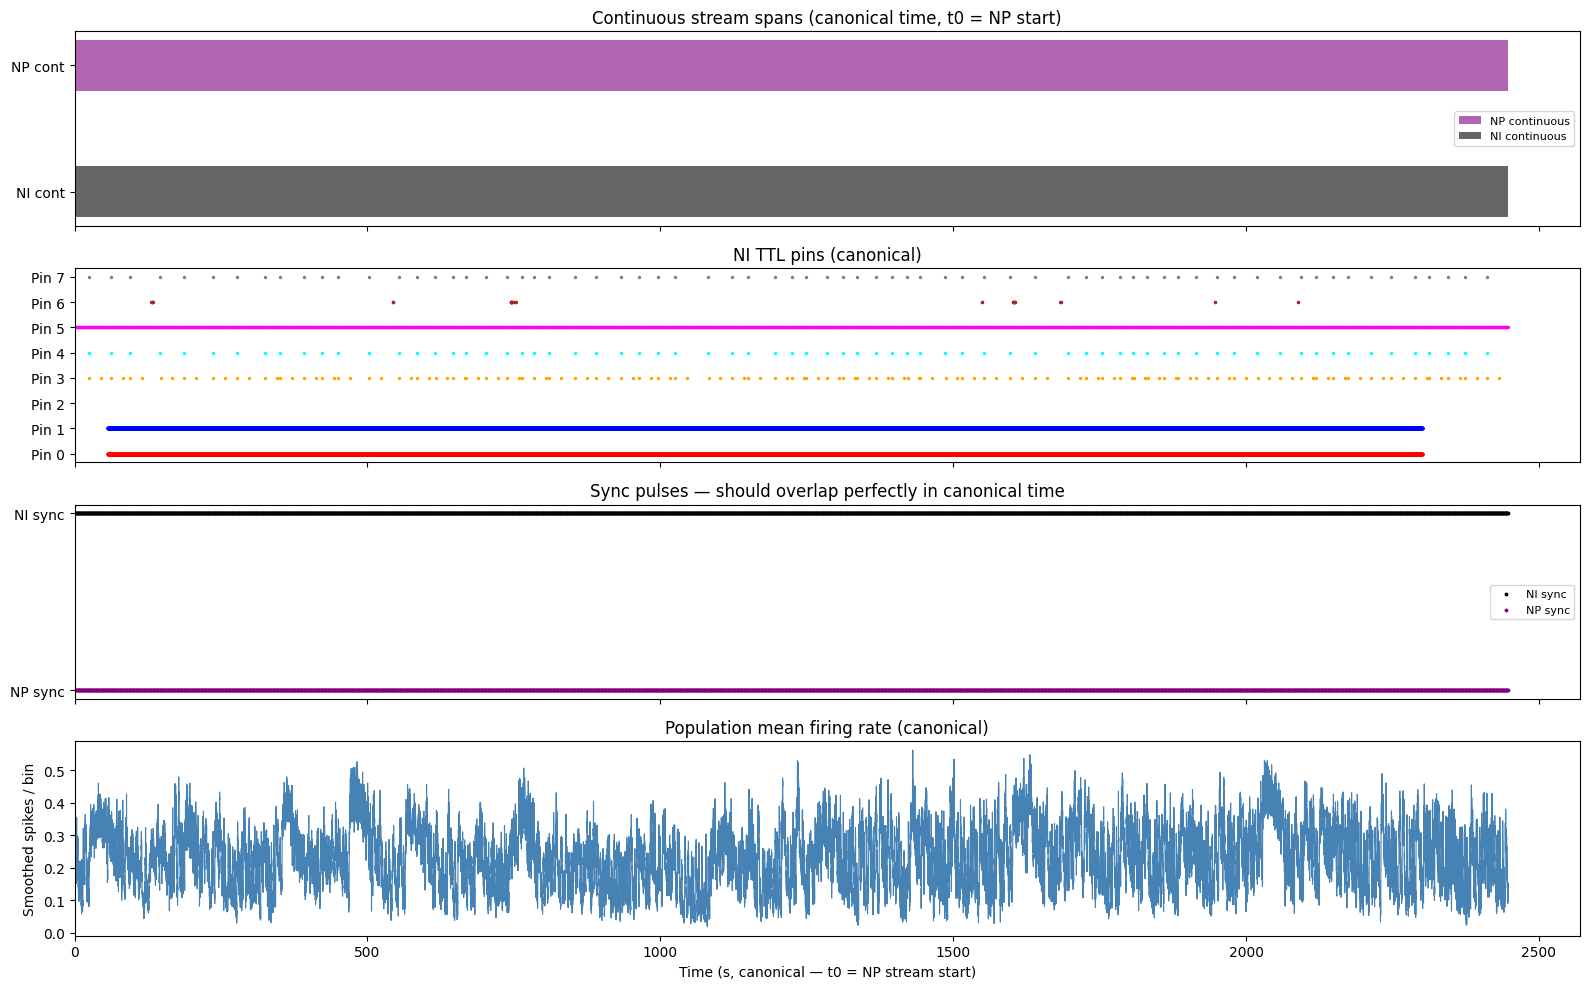

===== CELL A COMPLETE =====



In [2]:
# ============================================================
# =======================  CELL A  ============================
# ========== ROOT CELL — TTLs + QC + PORTABLE SPIKES =========
# ========== WITH NP ↔ NI CLOCK ALIGNMENT (SYNC) =============
# ============================================================

import os
import json
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

print("\n===== CELL A — ROOT PORTABLE EXTRACTION + NP↔NI ALIGNMENT =====")

# ------------------------------------------------------------
# USER INPUTS
# ------------------------------------------------------------

SESSION_FOLDER = r"D:\Kevin\04032026"

NI_TTL_FOLDER = r"G:\Kevin\2026-03-04_08-31-33\Record Node 104\experiment1\recording1\events\NI-DAQmx-103.PXIe-6341\TTL"
PROBEA_PATH   = r"G:\Kevin\2026-03-04_08-31-33\Record Node 101\experiment1\recording1\continuous\Neuropix-PXI-100.ProbeA\kilosort4"

EXPERIMENT_NUMBER = 1

CAMERA_TTL_PIN = 1
EXPECTED_RATE_HZ = 60
MISSING_TTL_THRESHOLD = 60
MIN_BLOCK_LENGTH = 500

FILENAME_PATTERN = r"frame_(\d+)_cnt_(\d+)\.raw"

NI_SYNC_BIT = 5
NP_SYNC_BIT = 0

NP_SAMPLE_RATE = 30000.0

print("User inputs loaded.")

# ------------------------------------------------------------
# UNIFIED ANALYSIS FOLDER
# ------------------------------------------------------------

def find_session_root(path):
    path = Path(path).resolve()
    while True:
        if "record node" in path.name.lower():
            return path
        parent = path.parent
        if parent == path:
            raise RuntimeError("Could not find 'Record Node' folder above given path")
        path = parent

def build_analysis_folder(session_root, experiment_number):
    experiment_folders = sorted(
        [f for f in session_root.iterdir()
         if f.is_dir() and f.name.lower().startswith("experiment")],
        key=lambda p: p.name
    )
    if experiment_number < 1 or experiment_number > len(experiment_folders):
        raise RuntimeError(f"Experiment {experiment_number} not found.")
    experiment_folder = experiment_folders[experiment_number - 1]
    recording_folders = sorted(
        [f for f in experiment_folder.iterdir()
         if f.is_dir() and f.name.lower().startswith("recording")],
        key=lambda p: p.name
    )
    if not recording_folders:
        raise RuntimeError("No recording folder found.")
    recording_folder = recording_folders[0]
    session_date = session_root.parent.name
    folder_name = f"{session_date}_{experiment_folder.name}_{recording_folder.name}_analysis"
    analysis_folder = session_root / folder_name
    analysis_folder.mkdir(exist_ok=True)
    for sf in ["qc","camera_alignment","dlc_alignment","behavior_ttls",
               "peak_detection","metadata","ttls","spikes"]:
        (analysis_folder / sf).mkdir(exist_ok=True)
    print(f"Analysis folder: {analysis_folder}")
    return analysis_folder

analysis_folder = build_analysis_folder(
    find_session_root(PROBEA_PATH), EXPERIMENT_NUMBER
)

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def save_incrementing(folder, base_name, array):
    folder = Path(folder)
    folder.mkdir(exist_ok=True)
    path = folder / f"{base_name}.npy"
    if not path.exists():
        np.save(path, array)
        return path
    counter = 1
    while True:
        path = folder / f"{base_name}_{counter}.npy"
        if not path.exists():
            np.save(path, array)
            return path
        counter += 1

def extract_rising_edges(full_words, timestamps, pin):
    mask = 1 << pin
    bit_on = (full_words & mask) > 0
    bit_prev = np.roll(bit_on, 1)
    bit_prev[0] = False
    rising = (~bit_prev) & bit_on
    return timestamps[rising]

# ------------------------------------------------------------
# LOAD CONTINUOUS TIMESTAMPS
# ------------------------------------------------------------

ni_ttl_folder    = Path(NI_TTL_FOLDER)
ni_device_name   = ni_ttl_folder.parent.name
recording_root   = ni_ttl_folder.parents[2]
ni_cont_folder   = recording_root / "continuous" / ni_device_name
probe_cont_folder = Path(PROBEA_PATH).parent

ni_cont_timestamps = np.load(ni_cont_folder   / "timestamps.npy")
np_cont_timestamps = np.load(probe_cont_folder / "timestamps.npy")

ni_start_abs = float(ni_cont_timestamps[0])
ni_end_abs   = float(ni_cont_timestamps[-1])
np_start_abs = float(np_cont_timestamps[0])
np_end_abs   = float(np_cont_timestamps[-1])

print(f"\nNI continuous (absolute): {ni_start_abs:.6f} → {ni_end_abs:.6f} s")
print(f"NP continuous (absolute): {np_start_abs:.6f} → {np_end_abs:.6f} s")

# ============================================================
# CANONICAL TIMEBASE DECISION
# ============================================================

t0 = np_start_abs

print(f"\nCanonical t0 = NP stream start = {t0:.6f} s (absolute)")
print(f"NI stream starts {ni_start_abs - t0:+.6f} s relative to t0")

# ------------------------------------------------------------
# SYNC PULSE ALIGNMENT: verify NP↔NI are on same clock
# ------------------------------------------------------------

print("\n===== NP ↔ NI SYNC ALIGNMENT =====")

timestamps_ni_ttl = np.load(ni_ttl_folder / "timestamps.npy")
full_words_ni     = np.load(ni_ttl_folder / "full_words.npy")

# Derive NP TTL folder from PROBEA_PATH, not hardcoded.
# PROBEA_PATH = .../<RecordNodeNP>/experimentN/recording1/continuous/Neuropix-PXI-XXX.ProbeA/kilosort4
# The TTL folder lives at:
# .../<RecordNodeNP>/experimentN/recording1/events/Neuropix-PXI-XXX.ProbeA/TTL
np_device_name    = probe_cont_folder.name                # Neuropix-PXI-XXX.ProbeA
np_recording_root = probe_cont_folder.parents[1]          # .../experimentN/recording1
np_ttl_folder     = np_recording_root / "events" / np_device_name / "TTL"

print(f"NI TTL folder: {ni_ttl_folder}")
print(f"NP TTL folder: {np_ttl_folder}")

if not np_ttl_folder.exists():
    raise FileNotFoundError(
        f"NP TTL folder not found:\n  {np_ttl_folder}\n"
        f"Check that PROBEA_PATH points to the correct kilosort4 folder."
    )

timestamps_np_ttl = np.load(np_ttl_folder / "timestamps.npy")
full_words_np     = np.load(np_ttl_folder / "full_words.npy")

sync_times_ni_abs = extract_rising_edges(full_words_ni, timestamps_ni_ttl, NI_SYNC_BIT)
sync_times_np_abs = extract_rising_edges(full_words_np, timestamps_np_ttl, NP_SYNC_BIT)

print(f"NI sync pulses (bit {NI_SYNC_BIT}): {len(sync_times_ni_abs)}")
print(f"NP sync pulses (bit {NP_SYNC_BIT}): {len(sync_times_np_abs)}")

if len(sync_times_ni_abs) == 0:
    raise RuntimeError("No NI sync pulses found.")
if len(sync_times_np_abs) == 0:
    raise RuntimeError("No NP sync pulses found.")

n_common = min(len(sync_times_np_abs), len(sync_times_ni_abs))
sync_np  = sync_times_np_abs[:n_common]
sync_ni  = sync_times_ni_abs[:n_common]

A_mat = np.vstack([sync_np, np.ones_like(sync_np)]).T
a_fit, b_fit = np.linalg.lstsq(A_mat, sync_ni, rcond=None)[0]
residuals = sync_ni - (a_fit * sync_np + b_fit)

print(f"\nLinear fit: t_NI = {a_fit:.9f} * t_NP + {b_fit:.9f}")
print(f"Residuals  mean={np.mean(residuals)*1000:.4f} ms  "
      f"std={np.std(residuals)*1000:.4f} ms  "
      f"max={np.max(np.abs(residuals))*1000:.4f} ms")

align_meta = {
    "np_to_ni_a": float(a_fit),
    "np_to_ni_b": float(b_fit),
    "n_pulses": int(n_common),
    "residual_mean_s": float(np.mean(residuals)),
    "residual_std_s":  float(np.std(residuals)),
    "residual_max_abs_s": float(np.max(np.abs(residuals))),
    "ni_sync_bit": int(NI_SYNC_BIT),
    "np_sync_bit": int(NP_SYNC_BIT),
    "t0_abs": float(t0),
    "ni_start_abs": float(ni_start_abs),
    "np_start_abs": float(np_start_abs),
    "ni_start_rel": float(ni_start_abs - t0),
    "ni_end_rel":   float(ni_end_abs   - t0),
    "np_start_rel": 0.0,
    "np_end_rel":   float(np_end_abs   - t0),
}
with open(analysis_folder / "metadata" / "np_ni_alignment.json", "w") as f:
    json.dump(align_meta, f, indent=2)
print(f"\nSaved alignment metadata.")

# ============================================================
# UNIFIED CONVERSION FUNCTIONS
# ============================================================

def np_samples_to_canonical(samples):
    return samples / NP_SAMPLE_RATE

def np_abs_to_canonical(t_np_abs):
    return t_np_abs - t0

def ni_abs_to_canonical(t_ni_abs):
    return t_ni_abs - t0

recording_duration = float(np_end_abs - t0)
print(f"\nRecording duration (canonical): {recording_duration:.3f} s")

# ============================================================
# CRITICAL DIAGNOSTIC: verify spike time anchor
# ============================================================

spike_times_raw = np.load(Path(PROBEA_PATH) / "spike_times.npy").flatten()
spike_times_sec_raw = spike_times_raw / NP_SAMPLE_RATE

ni_start_rel = ni_start_abs - t0

print(f"\n===== SPIKE TIME ANCHOR DIAGNOSTIC =====")
print(f"NI stream offset from NP start: {ni_start_rel:+.6f} s")
print(f"First 5 spike times (raw, seconds from sample 0): "
      f"{spike_times_sec_raw[:5]}")
print(f"Last  5 spike times (raw, seconds from sample 0): "
      f"{spike_times_sec_raw[-5:]}")
print(f"Expected canonical range: 0 → {recording_duration:.3f} s")
print(f"If spikes appear in range {-ni_start_rel:.3f} → "
      f"{recording_duration - ni_start_rel:.3f} s")
print(f"  → spike_times are anchored to NI start, not NP start.")
print(f"  → You need: spike_canonical = spikes_sec - {ni_start_rel:.6f}")
print(f"If spikes appear in range 0 → {recording_duration:.3f} s")
print(f"  → spike_times are anchored to NP start (correct, no adjustment).")

spike_min = float(spike_times_sec_raw.min())
spike_max = float(spike_times_sec_raw.max())

if abs(spike_min) < 5.0 and spike_max <= recording_duration + 5.0:
    print("\n→ AUTO-DETECTED: spikes anchored to NP start. No offset needed.")
    spike_anchor_offset = 0.0
elif abs(spike_min - ni_start_rel) < 5.0:
    print(f"\n→ AUTO-DETECTED: spikes anchored to NI start. "
          f"Applying offset of -{ni_start_rel:.6f} s.")
    spike_anchor_offset = ni_start_rel
else:
    print(f"\n→ WARNING: spike anchor unclear. "
          f"spike_min={spike_min:.3f}, ni_start_rel={ni_start_rel:.6f}. "
          f"Defaulting to 0 offset — PLEASE VERIFY MANUALLY.")
    spike_anchor_offset = 0.0

print(f"spike_anchor_offset = {spike_anchor_offset:.6f} s")

def spikes_to_canonical(spike_samples):
    return spike_samples / NP_SAMPLE_RATE - spike_anchor_offset

# ============================================================
# NI TTL EXTRACTION → canonical time
# ============================================================

print("\n===== EXTRACTING NI TTLs → CANONICAL TIME =====")

ttls_dir = analysis_folder / "ttls"
all_pin_ttls = {}

for pin in range(8):
    ttls_abs = extract_rising_edges(full_words_ni, timestamps_ni_ttl, pin)
    ttls_can = ni_abs_to_canonical(ttls_abs)
    all_pin_ttls[pin] = ttls_can
    save_incrementing(ttls_dir, f"TTL_Pin_{pin}", ttls_can)
    print(f"  Pin {pin}: {len(ttls_can)} TTLs", end="")
    if len(ttls_can):
        print(f"  range {ttls_can[0]:.3f} → {ttls_can[-1]:.3f} s")
    else:
        print()

ni_meta = {
    "canonical_t0_is": "NP stream start (np_start_abs)",
    "t0_abs": float(t0),
    "ni_start_canonical": float(ni_start_abs - t0),
    "ni_end_canonical":   float(ni_end_abs   - t0),
    "np_start_canonical": 0.0,
    "np_end_canonical":   float(np_end_abs   - t0),
    "recording_duration": float(recording_duration),
    "camera_ttl_pin": int(CAMERA_TTL_PIN),
    "expected_rate_hz": EXPECTED_RATE_HZ,
    "spike_anchor_offset_s": float(spike_anchor_offset),
}
with open(analysis_folder / "metadata" / "ttl_metadata.json", "w") as f:
    json.dump(ni_meta, f, indent=2)
print("Saved TTL metadata.")

# ============================================================
# TTL BLOCK DETECTION
# ============================================================

print("\n===== TTL BLOCK DETECTOR =====")

rising_times = all_pin_ttls[CAMERA_TTL_PIN]
print(f"Camera pin {CAMERA_TTL_PIN}: {len(rising_times)} rising edges")

ipi           = np.diff(rising_times)
expected_ipi  = 1.0 / EXPECTED_RATE_HZ
gap_threshold = expected_ipi * MISSING_TTL_THRESHOLD
gap_indices   = np.where(ipi > gap_threshold)[0]

block_starts = np.insert(gap_indices + 1, 0, 0)
block_ends   = np.append(gap_indices, len(rising_times) - 1)

ttl_blocks = []
block_info = []
cam_align_dir = analysis_folder / "camera_alignment"

for b_idx, (start, end) in enumerate(zip(block_starts, block_ends)):
    block_len = end - start + 1
    if block_len < MIN_BLOCK_LENGTH:
        print(f"  Skipping block {b_idx} (too short: {block_len})")
        continue
    block_times = rising_times[start:end+1]
    ttl_blocks.append(block_times)
    info = {
        "block_index": b_idx,
        "n_ttls": int(block_len),
        "start_canonical": float(block_times[0]),
        "end_canonical":   float(block_times[-1]),
        "duration_s":      float(block_times[-1] - block_times[0]),
    }
    block_info.append(info)
    save_incrementing(cam_align_dir, f"ttl_times_block{b_idx}", block_times)
    print(f"  Block {b_idx}: {block_len} TTLs, "
          f"{block_times[0]:.3f} → {block_times[-1]:.3f} s (canonical)")

with open(analysis_folder / "metadata" / "block_info.json", "w") as f:
    json.dump(block_info, f, indent=2)

# ============================================================
# QC: FIRING-RATE MATRIX
# ============================================================

print("\n===== QC: FIRING-RATE MATRIX =====")

qc_dir        = analysis_folder / "qc"
spikes_dir    = analysis_folder / "spikes"

rate_path          = qc_dir / "rate_matrix.npy"
good_units_path    = qc_dir / "good_units.npy"
centers_path       = qc_dir / "centers.npy"
duration_path      = qc_dir / "recording_duration.json"
noise_units_path   = qc_dir / "noise_units.npy"
noise_rate_path    = qc_dir / "noise_rate_matrix.npy"
spike_anchor_path  = qc_dir / "spike_anchor_offset.json"

all_qc_exist = all(p.exists() for p in [
    rate_path, good_units_path, centers_path, duration_path,
    noise_units_path, noise_rate_path
])

if all_qc_exist:
    print("QC files already exist — skipping.")
else:
    print("Computing QC...")

    spike_times_raw  = np.load(Path(PROBEA_PATH) / "spike_times.npy").flatten()
    spike_clusters   = np.load(Path(PROBEA_PATH) / "spike_clusters.npy").flatten()
    spike_times_can  = spikes_to_canonical(spike_times_raw)

    print(f"Spike time canonical range: "
          f"{spike_times_can.min():.3f} → {spike_times_can.max():.3f} s")
    print(f"Recording duration:          0.000 → {recording_duration:.3f} s")

    if spike_times_can.max() < recording_duration * 0.9:
        print("WARNING: spikes end well before recording end — "
              "check spike_anchor_offset!")
    if spike_times_can.min() < -1.0:
        print("WARNING: spikes start before t=0 — check spike_anchor_offset!")

    df_info    = pd.read_csv(Path(PROBEA_PATH) / "cluster_info.tsv", sep="\t")
    good_units = df_info[df_info["group"] == "good"]["id"].values
    np.save(good_units_path, good_units)
    print(f"Good units: {len(good_units)}")

    for unit in good_units:
        unit_spikes = spike_times_can[spike_clusters == unit]
        np.save(spikes_dir / f"unit_{unit}.npy", unit_spikes)

    noise_units = df_info[df_info["group"] == "noise"]["id"].values
    np.random.seed(0)
    sampled_noise = (np.random.choice(noise_units, size=min(20, len(noise_units)),
                                      replace=False))
    np.save(noise_units_path, sampled_noise)

    for unit in sampled_noise:
        unit_spikes = spike_times_can[spike_clusters == unit]
        np.save(spikes_dir / f"noise_unit_{unit}.npy", unit_spikes)

    with open(spike_anchor_path, "w") as f:
        json.dump({"spike_anchor_offset_s": float(spike_anchor_offset),
                   "t0_abs": float(t0)}, f, indent=2)

    bin_size = 0.02
    bins    = np.arange(0, recording_duration + bin_size, bin_size)
    centers = bins[:-1] + bin_size / 2
    np.save(centers_path, centers)
    with open(duration_path, "w") as f:
        json.dump({"recording_duration": recording_duration,
                   "t0_abs": float(t0)}, f, indent=2)

    def make_rate_matrix(unit_list, label):
        mat = np.zeros((len(unit_list), len(centers)), float)
        for i, unit in enumerate(unit_list):
            spk = spike_times_can[spike_clusters == unit]
            h, _ = np.histogram(spk, bins=bins)
            mat[i] = gaussian_filter1d(h.astype(float), sigma=2)
        return mat

    rate_matrix       = make_rate_matrix(good_units,   "good")
    noise_rate_matrix = make_rate_matrix(sampled_noise,"noise")
    np.save(rate_path,       rate_matrix)
    np.save(noise_rate_path, noise_rate_matrix)
    print(f"Saved rate_matrix {rate_matrix.shape}")
    print(f"Saved noise_rate_matrix {noise_rate_matrix.shape}")

# ============================================================
# DIAGNOSTIC PLOT — canonical timeline
# ============================================================

print("\n===== CANONICAL TIMELINE DIAGNOSTIC =====")

fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)

for ax in axes[:1]:
    ax.barh(1, recording_duration,       left=0,
            height=0.4, color='purple', alpha=0.6, label="NP continuous")
    ax.barh(0, ni_end_abs - t0,          left=ni_start_abs - t0,
            height=0.4, color='black',  alpha=0.6, label="NI continuous")
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["NI cont", "NP cont"])
    ax.legend(fontsize=8)
    ax.set_title("Continuous stream spans (canonical time, t0 = NP start)")

colors8 = ['red','blue','green','orange','cyan','magenta','brown','gray']
ax1 = axes[1]
for pin in range(8):
    tt = all_pin_ttls[pin]
    ax1.scatter(tt, np.full_like(tt, pin), s=2, color=colors8[pin],
                label=f"Pin {pin}")
ax1.set_yticks(range(8))
ax1.set_yticklabels([f"Pin {p}" for p in range(8)])
ax1.set_title("NI TTL pins (canonical)")

ax2 = axes[2]
sync_ni_can  = ni_abs_to_canonical(sync_times_ni_abs)
sync_np_can  = np_abs_to_canonical(sync_times_np_abs)
ax2.scatter(sync_ni_can, np.ones_like(sync_ni_can)*1,
            s=3, color='black', label="NI sync")
ax2.scatter(sync_np_can, np.ones_like(sync_np_can)*0,
            s=3, color='purple', label="NP sync")
ax2.set_yticks([0, 1])
ax2.set_yticklabels(["NP sync","NI sync"])
ax2.set_title("Sync pulses — should overlap perfectly in canonical time")
ax2.legend(fontsize=8)

ax3 = axes[3]
if centers_path.exists():
    centers_saved = np.load(centers_path)
    rm = np.load(rate_path)
    ax3.plot(centers_saved, rm.mean(axis=0), color='steelblue', lw=0.8)
    ax3.set_title("Population mean firing rate (canonical)")
    ax3.set_ylabel("Smoothed spikes / bin")

axes[-1].set_xlabel("Time (s, canonical — t0 = NP stream start)")
plt.tight_layout()
plt.show()

print("===== CELL A COMPLETE =====\n")

In [3]:
# ============================================================
# CELL B — FRAME ALIGNMENT (RIG-ONLY) — CORRECTED
# ============================================================
# Camera behavior assumed (confirmed by Kevin):
#   - frame_idx resets to 0 each block; contiguous (no gaps)
#   - first saved frame == TTL #0 of the block
#   - cnt is a free-running counter (offset is arbitrary).
#     Drops show up as gaps in cnt.
#
# Mapping: saved frame at position p
#          → ttl_index_in_block = cnt[p] - cnt[0]
#          → canonical_time     = ttl_times_block[cnt[p] - cnt[0]]
# ============================================================
import os, re, json
import numpy as np
from pathlib import Path

print("\n===== CELL B — FRAME ALIGNMENT (RIG) =====")

required_vars = ["analysis_folder", "ttl_blocks", "FILENAME_PATTERN"]
for v in required_vars:
    if v not in globals():
        raise RuntimeError(f"'{v}' missing — run Cell A first.")

# ------------------------------------------------------------
# USER EDIT — camera folder per block
# ------------------------------------------------------------
CAM_FOLDERS = {
    0: r"D:\Kevin\04032026\04032026-1\cam2",
}
# ------------------------------------------------------------

if len(CAM_FOLDERS) != len(ttl_blocks):
    raise ValueError(f"CAM_FOLDERS has {len(CAM_FOLDERS)} entries "
                     f"but there are {len(ttl_blocks)} TTL blocks.")
if set(CAM_FOLDERS.keys()) != set(range(len(ttl_blocks))):
    raise ValueError(f"CAM_FOLDERS keys must be {set(range(len(ttl_blocks)))}.")
for b, p in CAM_FOLDERS.items():
    if not os.path.isdir(p):
        raise FileNotFoundError(f"Camera folder for block {b} missing: {p}")

PATTERN = re.compile(FILENAME_PATTERN)
cam_align_dir = analysis_folder / "camera_alignment"
cam_align_dir.mkdir(exist_ok=True)

# ------------------------------------------------------------
# PROCESS EACH BLOCK
# ------------------------------------------------------------
for block_index, ttl_times_block in enumerate(ttl_blocks):

    print(f"\n--- Block {block_index} ---")
    cam_folder = CAM_FOLDERS[block_index]
    n_ttls = len(ttl_times_block)
    print(f"TTLs in block: {n_ttls}")
    print(f"Camera folder: {cam_folder}")

    # Scan filenames
    entries = []
    for fname in os.listdir(cam_folder):
        m = PATTERN.match(fname)
        if m:
            entries.append((int(m.group(1)), int(m.group(2)), fname))
    if not entries:
        raise RuntimeError(f"No matching files in {cam_folder}")

    entries.sort(key=lambda e: e[1])  # sort by cnt
    frame_idx_arr = np.array([e[0] for e in entries], dtype=np.int64)
    cnt_arr       = np.array([e[1] for e in entries], dtype=np.int64)

    n_saved   = len(entries)
    first_cnt = int(cnt_arr[0])
    last_cnt  = int(cnt_arr[-1])
    cnt_span  = last_cnt - first_cnt + 1   # TTLs covered by camera save window

    print(f"Saved frames: {n_saved}")
    print(f"frame_idx range: {int(frame_idx_arr[0])} → {int(frame_idx_arr[-1])}")
    print(f"cnt range: {first_cnt} → {last_cnt}")
    print(f"cnt span (TTLs covered by camera): {cnt_span}")
    print(f"Implied drops within camera window: {cnt_span - n_saved}")

    # ----- Invariant 1: first frame_idx must be 0 -----
    if int(frame_idx_arr[0]) != 0:
        raise RuntimeError(
            f"Block {block_index}: first saved frame has frame_idx="
            f"{int(frame_idx_arr[0])}, expected 0. Camera should reset "
            f"frame_idx to 0 at block start."
        )

    # ----- Invariant 2: frame_idx contiguous (no gaps) -----
    fidx_gaps = np.where(np.diff(frame_idx_arr) != 1)[0]
    if len(fidx_gaps) > 0:
        raise RuntimeError(
            f"Block {block_index}: frame_idx has gaps at positions "
            f"{fidx_gaps[:5].tolist()}{'...' if len(fidx_gaps) > 5 else ''}. "
            f"frame_idx should be contiguous; drops live in cnt only."
        )

    # ----- Invariant 3: cnt span fits within TTL block -----
    # The camera can stop saving before the last TTL (trailing TTLs are
    # benign). It must NOT extend past the TTL block.
    if cnt_span > n_ttls:
        raise RuntimeError(
            f"Block {block_index}: cnt span ({cnt_span}) exceeds TTL count "
            f"({n_ttls}). The camera appears to have received more TTLs "
            f"than the TTL detector found, which means the block "
            f"boundaries are wrong."
        )

    # ----- Invariant 4: how much TTL hangs off the end? Report it. -----
    trailing_ttls = n_ttls - cnt_span
    trailing_secs = (ttl_times_block[-1] - ttl_times_block[cnt_span - 1]
                     if cnt_span > 0 else 0.0)
    print(f"Trailing TTLs after camera stopped: {trailing_ttls} "
          f"(~{trailing_secs:.2f} s)")
    if trailing_ttls > n_ttls * 0.1:
        print(f"  WARNING: more than 10% of TTLs are trailing. "
              f"Check that you didn't stop the camera way before "
              f"stopping OpenEphys.")

    # ------------------------------------------------------------
    # CORE MAPPING
    # ------------------------------------------------------------
    # For each saved frame, compute its TTL index in the block
    # and look up the canonical time.
    # ------------------------------------------------------------
    ttl_idx_in_block = cnt_arr - first_cnt          # shape (n_saved,)
    frame_canonical_times = ttl_times_block[ttl_idx_in_block]

    # Sanity: monotonic increasing
    if not np.all(np.diff(frame_canonical_times) > 0):
        raise RuntimeError(
            f"Block {block_index}: frame canonical times are not strictly "
            f"increasing. This indicates a sorting or cnt error."
        )

    # ------------------------------------------------------------
    # SAVE PORTABLE ARRAYS
    # ------------------------------------------------------------
    np.save(cam_align_dir / f"frame_cnt_block{block_index}.npy", cnt_arr)
    np.save(cam_align_dir / f"frame_canonical_times_block{block_index}.npy",
            frame_canonical_times)

    print(f"Wrote frame_cnt_block{block_index}.npy "
          f"and frame_canonical_times_block{block_index}.npy")
    print(f"Frame canonical time range: "
          f"{frame_canonical_times[0]:.3f} → {frame_canonical_times[-1]:.3f} s")

# ------------------------------------------------------------
# Save frame-alignment metadata
# ------------------------------------------------------------
frame_meta = {
    str(b): {
        "cam_folder": CAM_FOLDERS[b],
        "n_saved_frames": int(np.load(cam_align_dir / f"frame_cnt_block{b}.npy").size),
        "n_ttls": int(len(ttl_blocks[b])),
        "first_cnt": int(np.load(cam_align_dir / f"frame_cnt_block{b}.npy")[0]),
        "last_cnt":  int(np.load(cam_align_dir / f"frame_cnt_block{b}.npy")[-1]),
    }
    for b in range(len(ttl_blocks))
}
with open(analysis_folder / "metadata" / "frame_alignment.json", "w") as f:
    json.dump(frame_meta, f, indent=2)

print("\n===== CELL B COMPLETE — RIG WORK DONE =====")
print("Everything below this point is portable.\n")


===== CELL B — FRAME ALIGNMENT (RIG) =====

--- Block 0 ---
TTLs in block: 134517
Camera folder: D:\Kevin\04032026\04032026-1\cam2
Saved frames: 120268
frame_idx range: 0 → 120267
cnt range: 394280 → 528195
cnt span (TTLs covered by camera): 133916
Implied drops within camera window: 13648
Trailing TTLs after camera stopped: 601 (~10.02 s)
Wrote frame_cnt_block0.npy and frame_canonical_times_block0.npy
Frame canonical time range: 57.140 → 2290.164 s

===== CELL B COMPLETE — RIG WORK DONE =====
Everything below this point is portable.



In [88]:
# ============================================================
# CELL C — SESSION BUILDER (PORTABLE)
# ============================================================
# First cell after the rig/home line. Defines DLC paths and
# writes session.json with all metadata needed for downstream
# analysis. Loads ttl_blocks etc. from disk if not in kernel.
# ============================================================
import os, json
import numpy as np
from pathlib import Path

print("\n===== CELL C — SESSION BUILDER (PORTABLE) =====")

# ------------------------------------------------------------
# USER EDIT — set analysis_folder if running on home machine
# ------------------------------------------------------------
# If you've just opened this notebook fresh on your home laptop,
# uncomment and edit this line:
# analysis_folder = Path(r"D:\path\to\..._analysis")
# ------------------------------------------------------------

if "analysis_folder" not in globals():
    raise RuntimeError("Set `analysis_folder` (Path to the analysis folder).")
analysis_folder = Path(analysis_folder)

# ------------------------------------------------------------
# USER EDIT — DLC outputs per block
# ------------------------------------------------------------
DLC_OUTPUTS = {
    0: r"F:\Mouse1_030926-Kevin-2026-05-07\videos\09032026-6_cam2DLC_Resnet50_Mouse1_030926May7shuffle1_snapshot_best-70.h5",
}
# ------------------------------------------------------------

# Pin labels — bake into session so downstream plots auto-label
PIN_LABELS = {
    0: "camera1",
    1: "camera2",
    3: "pellet_motor",   # 2 turns/trial: expose + retract
    4: "tone_cue",
    5: "np_sync_1hz",
    6: "reach_ir_beam",
    7: "manual_pellet_button",
}
CAMERA_TTL_PIN = 1  # this session uses cam2

# ------------------------------------------------------------
# LOAD CELL A METADATA FROM DISK
# ------------------------------------------------------------
with open(analysis_folder / "metadata" / "np_ni_alignment.json") as f:
    align_meta = json.load(f)
with open(analysis_folder / "metadata" / "ttl_metadata.json") as f:
    ttl_meta = json.load(f)
with open(analysis_folder / "metadata" / "block_info.json") as f:
    block_info = json.load(f)
with open(analysis_folder / "metadata" / "frame_alignment.json") as f:
    frame_meta = json.load(f)

# ------------------------------------------------------------
# RELOAD ttl_blocks AND all_pin_ttls FROM DISK IF NEEDED
# ------------------------------------------------------------
cam_align_dir = analysis_folder / "camera_alignment"
ttls_dir = analysis_folder / "ttls"

ttl_blocks = []
for bi in block_info:
    idx = bi["block_index"]
    ttl_blocks.append(np.load(cam_align_dir / f"ttl_times_block{idx}.npy"))

all_pin_ttls = {}
for pin in range(8):
    p = ttls_dir / f"TTL_Pin_{pin}.npy"
    all_pin_ttls[pin] = np.load(p) if p.exists() else np.array([])

# ------------------------------------------------------------
# VALIDATE DLC MAPPING
# ------------------------------------------------------------
if len(DLC_OUTPUTS) != len(ttl_blocks):
    raise ValueError(f"DLC_OUTPUTS has {len(DLC_OUTPUTS)} entries "
                     f"but there are {len(ttl_blocks)} TTL blocks.")
if set(DLC_OUTPUTS.keys()) != set(range(len(ttl_blocks))):
    raise ValueError(f"DLC_OUTPUTS keys must be {set(range(len(ttl_blocks)))}.")
for b, path in DLC_OUTPUTS.items():
    if not os.path.isfile(path):
        raise FileNotFoundError(f"DLC file for block {b} missing: {path}")

# ------------------------------------------------------------
# BUILD SESSION OBJECT
# ------------------------------------------------------------
session = {
    "canonical_t0_abs":         align_meta["t0_abs"],
    "canonical_t0_description": "NP stream start (absolute OpenEphys clock seconds)",
    "recording_duration_s":     ttl_meta["recording_duration"],
    "spike_anchor_offset_s":    ttl_meta["spike_anchor_offset_s"],
    "np_to_ni_a":               align_meta["np_to_ni_a"],
    "np_to_ni_b":               align_meta["np_to_ni_b"],
    "camera_ttl_pin":           CAMERA_TTL_PIN,
    "pin_labels":               PIN_LABELS,
    "blocks": []
}

for block_index, ttl_times_block in enumerate(ttl_blocks):
    fm = frame_meta[str(block_index)]
    session["blocks"].append({
        "block_index":              block_index,
        "n_ttls":                   int(len(ttl_times_block)),
        "n_saved_frames":           int(fm["n_saved_frames"]),
        "start_canonical":          float(ttl_times_block[0]),
        "end_canonical":            float(ttl_times_block[-1]),
        "ttl_times_path":           str(cam_align_dir / f"ttl_times_block{block_index}.npy"),
        "frame_cnt_path":           str(cam_align_dir / f"frame_cnt_block{block_index}.npy"),
        "frame_canonical_times_path": str(cam_align_dir / f"frame_canonical_times_block{block_index}.npy"),
        "dlc_path":                 DLC_OUTPUTS[block_index],
        "dlc_canonical_path":       str(analysis_folder / "dlc_alignment" / f"dlc_canonical_block{block_index}.npz"),
    })

session_path = analysis_folder / "metadata" / "session.json"
with open(session_path, "w") as f:
    json.dump(session, f, indent=2)

print(f"Saved session.json → {session_path}")
print(f"\nSession summary:")
print(f"  canonical t0 (abs):  {session['canonical_t0_abs']:.6f} s")
print(f"  recording duration:  {session['recording_duration_s']:.3f} s")
print(f"  spike_anchor_offset: {session['spike_anchor_offset_s']:.6f} s")
print(f"  camera TTL pin:      {session['camera_ttl_pin']}")
for b in session["blocks"]:
    print(f"  Block {b['block_index']}: {b['n_ttls']} TTLs, "
          f"{b['n_saved_frames']} saved frames, "
          f"{b['start_canonical']:.3f} → {b['end_canonical']:.3f} s")

print("\n===== CELL C COMPLETE =====\n")


===== CELL C — SESSION BUILDER (PORTABLE) =====
Saved session.json → G:\Kevin\2026-03-09_14-29-25\Record Node 114\2026-03-09_14-29-25_experiment2_recording1_analysis\metadata\session.json

Session summary:
  canonical t0 (abs):  171.412843 s
  recording duration:  1992.203 s
  spike_anchor_offset: 0.000000 s
  camera TTL pin:      1
  Block 0: 116497 TTLs, 102592 saved frames, 12.608 → 1955.368 s

===== CELL C COMPLETE =====



In [89]:
# ============================================================
# CELL D — DLC ↔ CANONICAL ALIGNMENT (PORTABLE)
# ============================================================
# For each block, reads the DLC .h5 (one row per saved frame in
# MP4 order, matches frame_idx because frame_idx is contiguous)
# and writes dlc_canonical_block{N}.npz containing:
#   canonical_time   : (n_saved,) float64
#   bodyparts        : list of bodypart names
#   {bp}_x, {bp}_y, {bp}_likelihood : (n_saved,) float32 each
# ============================================================
import json
import numpy as np
import pandas as pd
from pathlib import Path

print("\n===== CELL D — DLC ↔ CANONICAL ALIGNMENT =====")

if "analysis_folder" not in globals():
    raise RuntimeError("Run Cell C first (or set analysis_folder).")

with open(analysis_folder / "metadata" / "session.json") as f:
    session = json.load(f)

dlc_dir = analysis_folder / "dlc_alignment"
dlc_dir.mkdir(exist_ok=True)

for block in session["blocks"]:
    b = block["block_index"]
    print(f"\n--- Block {b} ---")

    frame_can_times = np.load(block["frame_canonical_times_path"])
    n_saved = len(frame_can_times)
    print(f"Saved frames (from frame_canonical_times): {n_saved}")

    dlc_path = Path(block["dlc_path"])
    print(f"Loading DLC: {dlc_path.name}")
    df = pd.read_hdf(dlc_path)
    n_rows = len(df)
    print(f"DLC rows: {n_rows}")

    if n_rows != n_saved:
        raise RuntimeError(
            f"Block {b}: DLC has {n_rows} rows but {n_saved} frames were "
            f"saved. They must match (DLC processes saved frames in order). "
            f"Common causes: DLC was run on a different video, or some "
            f"frames were trimmed before DLC."
        )

    # MultiIndex: (scorer, bodypart, coord). Pull bodyparts list.
    bodyparts = list(dict.fromkeys(df.columns.get_level_values("bodyparts")))
    print(f"Bodyparts found: {bodyparts}")

    out = {"canonical_time": frame_can_times.astype(np.float64),
           "bodyparts": np.array(bodyparts)}

    scorer = df.columns.get_level_values("scorer")[0]
    for bp in bodyparts:
        out[f"{bp}_x"]          = df[(scorer, bp, "x")].to_numpy(dtype=np.float32)
        out[f"{bp}_y"]          = df[(scorer, bp, "y")].to_numpy(dtype=np.float32)
        out[f"{bp}_likelihood"] = df[(scorer, bp, "likelihood")].to_numpy(dtype=np.float32)

    out_path = Path(block["dlc_canonical_path"])
    np.savez(out_path, **out)
    print(f"Saved → {out_path.name}")
    print(f"Time range: {frame_can_times[0]:.3f} → {frame_can_times[-1]:.3f} s")

print("\n===== CELL D COMPLETE =====\n")


===== CELL D — DLC ↔ CANONICAL ALIGNMENT =====

--- Block 0 ---
Saved frames (from frame_canonical_times): 102592
Loading DLC: 09032026-6_cam2DLC_Resnet50_Mouse1_030926May7shuffle1_snapshot_best-70.h5
DLC rows: 102592
Bodyparts found: ['paw', 'digit1', 'digit2', 'nose', 'tongue']
Saved → dlc_canonical_block0.npz
Time range: 12.608 → 1945.362 s

===== CELL D COMPLETE =====



In [90]:
# ============================================================
# CELL E — FULL-SESSION DLC TRAJECTORY BUILDER (PORTABLE)
# ============================================================
# Concatenates per-block DLC into one full-session .npz:
#   full_session_dlc.npz
#     canonical_time   : (n_total_saved,)
#     block_index      : (n_total_saved,)
#     {bp}_x, {bp}_y, {bp}_likelihood for each bodypart
#
# After this, NO downstream cell needs to touch DLC .h5 files
# or per-block .npz files. Everything loads from this one file.
# ============================================================
import json
import numpy as np
from pathlib import Path

print("\n===== CELL E — FULL-SESSION DLC BUILDER =====")

if "analysis_folder" not in globals():
    raise RuntimeError("Set analysis_folder.")

with open(analysis_folder / "metadata" / "session.json") as f:
    session = json.load(f)

# Load block 0 first to learn the bodypart list
b0 = session["blocks"][0]
d0 = np.load(b0["dlc_canonical_path"], allow_pickle=True)
bodyparts = [str(x) for x in d0["bodyparts"]]
print(f"Bodyparts: {bodyparts}")

# Concatenate
all_t      = []
all_block  = []
all_data   = {f"{bp}_{coord}": []
              for bp in bodyparts
              for coord in ["x", "y", "likelihood"]}

for block in session["blocks"]:
    b = block["block_index"]
    d = np.load(block["dlc_canonical_path"], allow_pickle=True)
    n = len(d["canonical_time"])
    print(f"  Block {b}: {n} frames, "
          f"{d['canonical_time'][0]:.3f} → {d['canonical_time'][-1]:.3f} s")

    all_t.append(d["canonical_time"])
    all_block.append(np.full(n, b, dtype=np.int16))
    for bp in bodyparts:
        for coord in ["x", "y", "likelihood"]:
            all_data[f"{bp}_{coord}"].append(d[f"{bp}_{coord}"])

out = {
    "canonical_time": np.concatenate(all_t),
    "block_index":    np.concatenate(all_block),
    "bodyparts":      np.array(bodyparts),
}
for k, v in all_data.items():
    out[k] = np.concatenate(v)

out_path = analysis_folder / "dlc_alignment" / "full_session_dlc.npz"
np.savez(out_path, **out)
print(f"\nSaved → {out_path}")
print(f"Total frames: {len(out['canonical_time'])}")
print(f"Time range: {out['canonical_time'][0]:.3f} → {out['canonical_time'][-1]:.3f} s")
print("\n===== CELL E COMPLETE =====\n")


===== CELL E — FULL-SESSION DLC BUILDER =====
Bodyparts: ['paw', 'digit1', 'digit2', 'nose', 'tongue']
  Block 0: 102592 frames, 12.608 → 1945.362 s

Saved → G:\Kevin\2026-03-09_14-29-25\Record Node 114\2026-03-09_14-29-25_experiment2_recording1_analysis\dlc_alignment\full_session_dlc.npz
Total frames: 102592
Time range: 12.608 → 1945.362 s

===== CELL E COMPLETE =====




===== CELL F — SANITY PLOTS =====


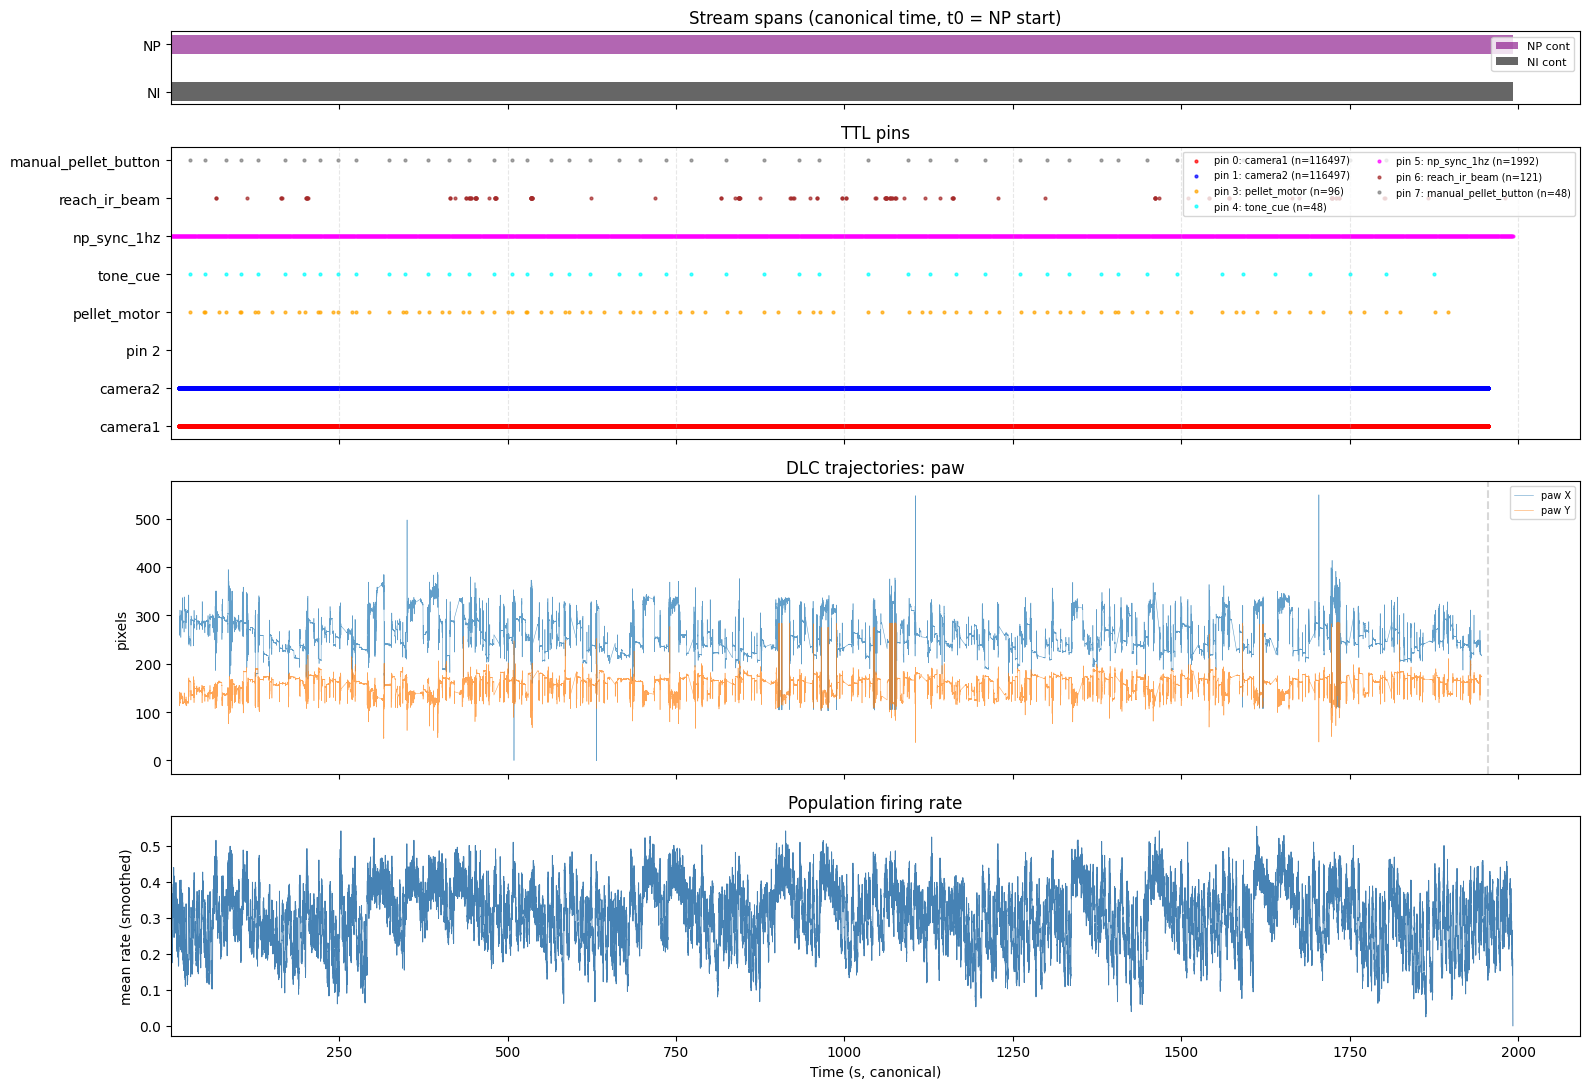


Saved → G:\Kevin\2026-03-09_14-29-25\Record Node 114\2026-03-09_14-29-25_experiment2_recording1_analysis\camera_alignment\sanity_overview.png

===== CELL F COMPLETE =====



In [91]:
# ============================================================
# CELL F — SANITY PLOTS (PORTABLE)
# ============================================================
# One figure with: TTL pins raster, frame saved/dropped bar,
# DLC trajectory for selected bodyparts, NP/NI spans.
# Loads only from analysis_folder/ — no raw data needed.
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("\n===== CELL F — SANITY PLOTS =====")

# ------------------------------------------------------------
# USER EDIT — which bodyparts to overlay
# ------------------------------------------------------------
PLOT_BODYPARTS = ["paw"]
# ------------------------------------------------------------

if "analysis_folder" not in globals():
    raise RuntimeError("Set analysis_folder.")

with open(analysis_folder / "metadata" / "session.json") as f:
    session = json.load(f)
with open(analysis_folder / "metadata" / "np_ni_alignment.json") as f:
    align_meta = json.load(f)

pin_labels = session["pin_labels"]
rec_dur    = session["recording_duration_s"]
ni_start   = align_meta["ni_start_rel"]
ni_end     = align_meta["ni_end_rel"]

# Load all TTL pins
ttls_dir = analysis_folder / "ttls"
all_pin_ttls = {}
for pin in range(8):
    p = ttls_dir / f"TTL_Pin_{pin}.npy"
    all_pin_ttls[pin] = np.load(p) if p.exists() else np.array([])

# Load full-session DLC
dlc_npz = np.load(analysis_folder / "dlc_alignment" / "full_session_dlc.npz")
dlc_t = dlc_npz["canonical_time"]

# Load population firing-rate trace
centers = np.load(analysis_folder / "qc" / "centers.npy")
rate_matrix = np.load(analysis_folder / "qc" / "rate_matrix.npy")
pop_rate = rate_matrix.mean(axis=0)

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------
fig, axes = plt.subplots(4, 1, figsize=(16, 11), sharex=True,
                         gridspec_kw={"height_ratios": [0.5, 2, 2, 1.5]})

# Row 0: NP / NI stream spans
ax = axes[0]
ax.barh(1, rec_dur, left=0, height=0.4, color="purple", alpha=0.6, label="NP cont")
ax.barh(0, ni_end - ni_start, left=ni_start, height=0.4, color="black", alpha=0.6, label="NI cont")
ax.set_yticks([0, 1]); ax.set_yticklabels(["NI", "NP"])
ax.legend(fontsize=8, loc="upper right")
ax.set_title("Stream spans (canonical time, t0 = NP start)")

# Row 1: TTL pin raster, color-coded with labels
ax = axes[1]
colors = ['red','blue','green','orange','cyan','magenta','brown','gray']
for pin in range(8):
    t = all_pin_ttls[pin]
    if len(t) == 0:
        continue
    label = pin_labels.get(str(pin), pin_labels.get(pin, f"pin {pin}"))
    ax.scatter(t, np.full_like(t, pin), s=4, color=colors[pin], alpha=0.7,
               label=f"pin {pin}: {label} (n={len(t)})")
ax.set_yticks(range(8))
ax.set_yticklabels([pin_labels.get(str(p), pin_labels.get(p, f"pin {p}"))
                    for p in range(8)])
ax.legend(fontsize=7, loc="upper right", ncol=2)
ax.set_title("TTL pins")
ax.grid(True, axis="x", linestyle="--", alpha=0.3)

# Row 2: DLC traces
ax = axes[2]
for bp in PLOT_BODYPARTS:
    if f"{bp}_x" not in dlc_npz.files:
        print(f"  WARNING: bodypart '{bp}' not in DLC file.")
        continue
    ax.plot(dlc_t, dlc_npz[f"{bp}_x"], lw=0.4, alpha=0.7, label=f"{bp} X")
    ax.plot(dlc_t, dlc_npz[f"{bp}_y"], lw=0.4, alpha=0.7, label=f"{bp} Y")
# block boundaries
for block in session["blocks"]:
    ax.axvline(block["end_canonical"], color="gray", linestyle="--", alpha=0.3)
ax.set_ylabel("pixels")
ax.legend(fontsize=7, loc="upper right")
ax.set_title(f"DLC trajectories: {', '.join(PLOT_BODYPARTS)}")

# Row 3: population firing rate
ax = axes[3]
ax.plot(centers, pop_rate, color="steelblue", lw=0.7)
ax.set_ylabel("mean rate (smoothed)")
ax.set_title("Population firing rate")
ax.set_xlabel("Time (s, canonical)")

plt.tight_layout()

# Save
save_dir = analysis_folder / "camera_alignment"
save_path = save_dir / "sanity_overview.png"
i = 1
while save_path.exists():
    save_path = save_dir / f"sanity_overview_{i}.png"; i += 1
fig.savefig(save_path, dpi=200)
plt.show()
print(f"\nSaved → {save_path}")
print("\n===== CELL F COMPLETE =====\n")


===== CELL G — PERI-EVENT DIAGNOSTIC =====
Event pin 4 (tone_cue): 48 TTLs

===== EVENT REFERENCE TABLE =====
  # |  canonical (s) | block | video frame | video time (s) | lookup err (ms)
--------------------------------------------------------------------------------
  1 |         28.095 |     0 |         929 |         15.483 |             5.7
  2 |         50.649 |     0 |        2281 |         38.017 |             1.2
  3 |         81.860 |     0 |        4153 |         69.217 |             6.7
  4 |        104.393 |     0 |        5504 |         91.733 |             3.7
  5 |        129.165 |     0 |        6989 |        116.483 |             3.3
  6 |        169.735 |     0 |        9422 |        157.033 |             1.1
  7 |        198.184 |     0 |       11128 |        185.467 |             2.6
  8 |        220.729 |     0 |       12480 |        208.000 |             4.4



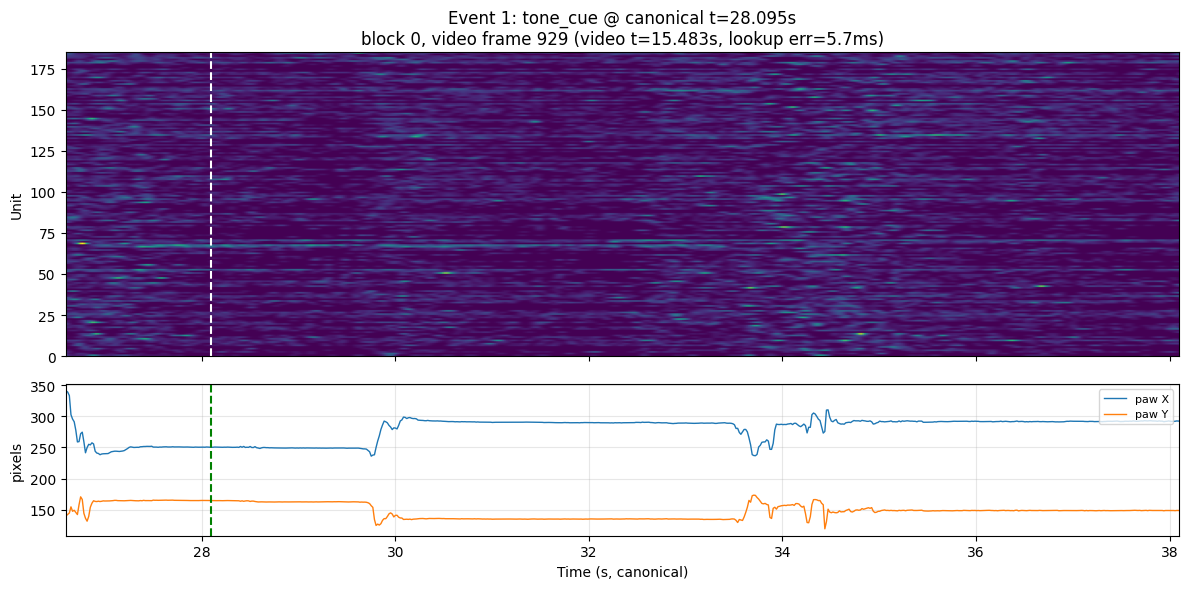

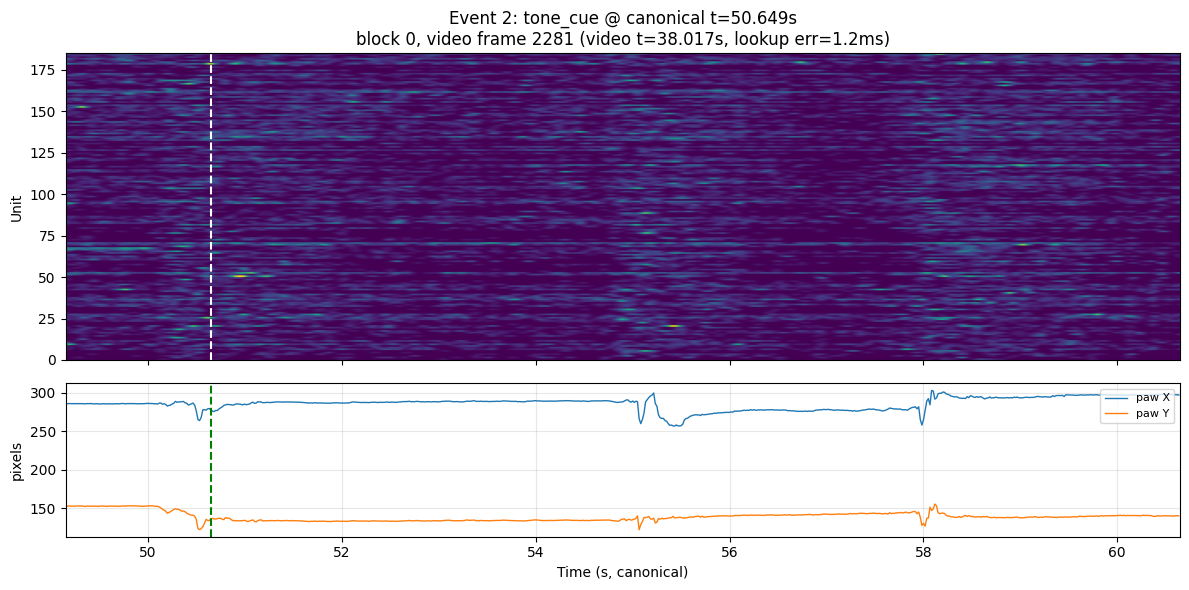

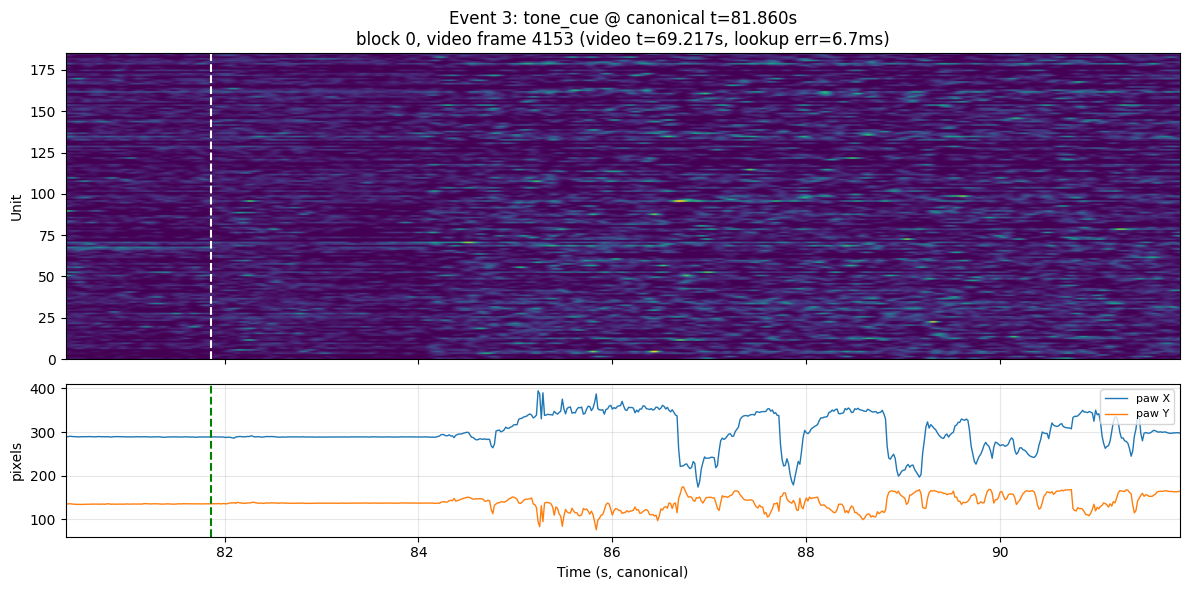

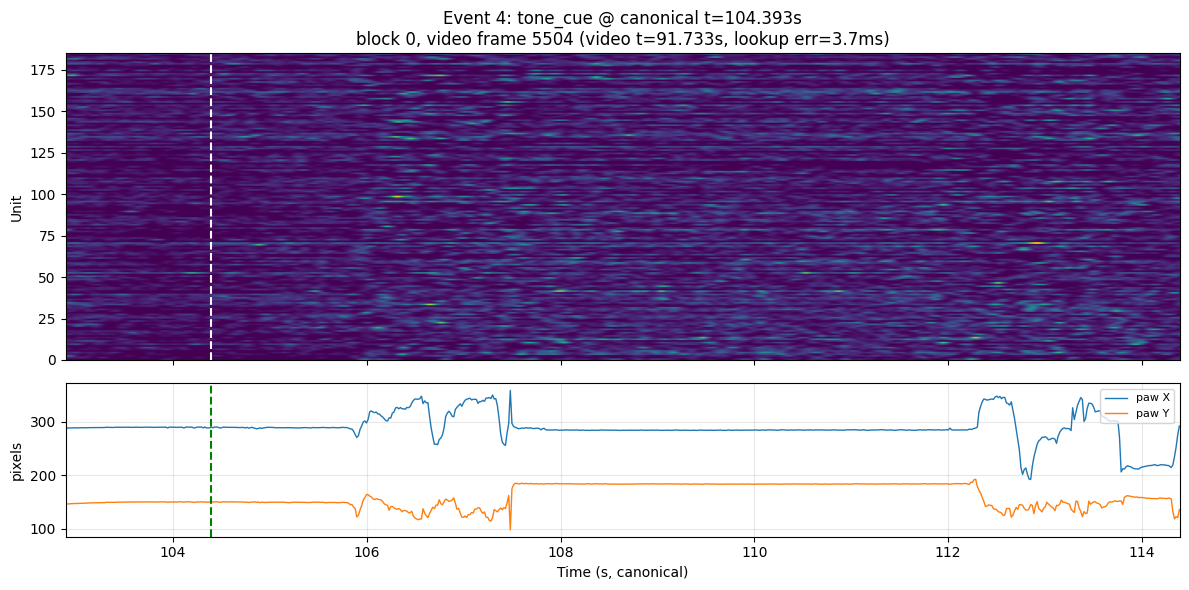

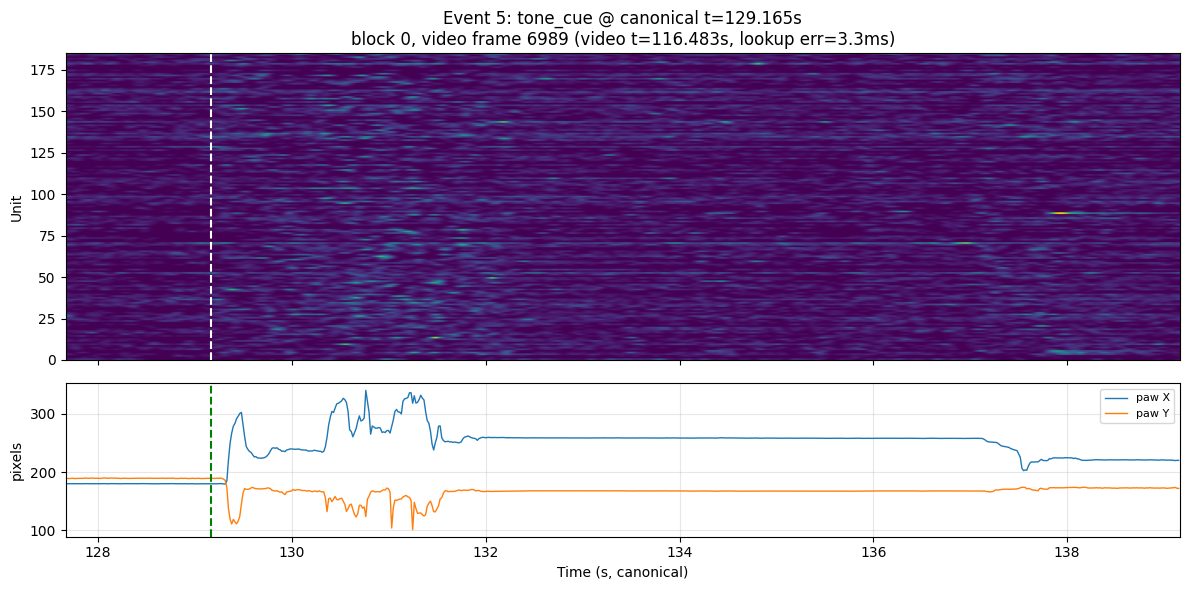

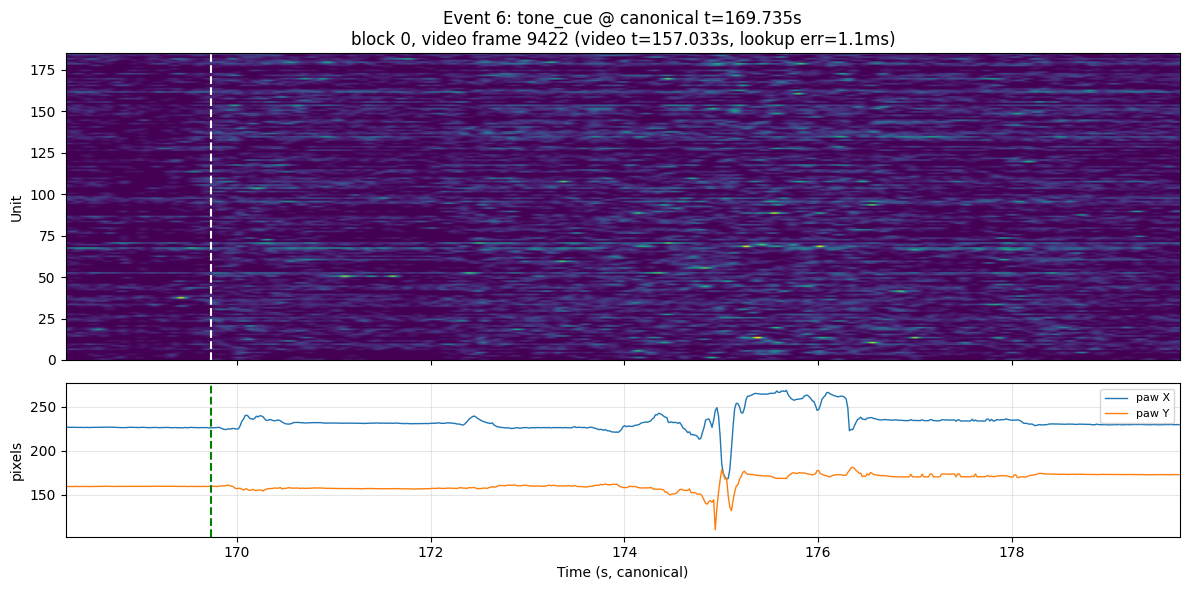

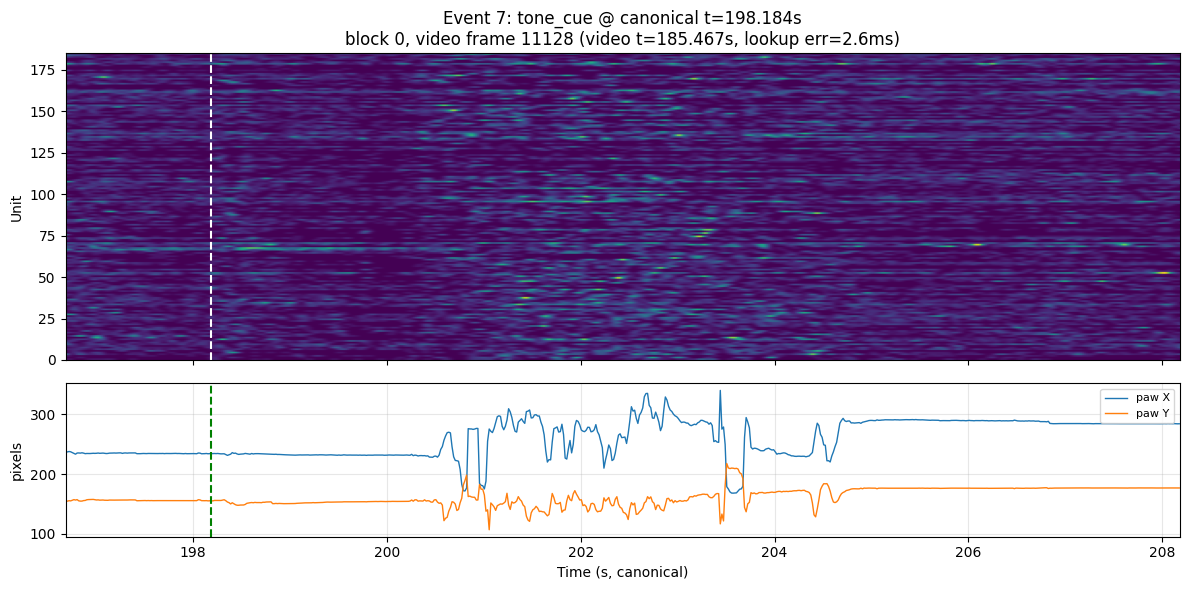

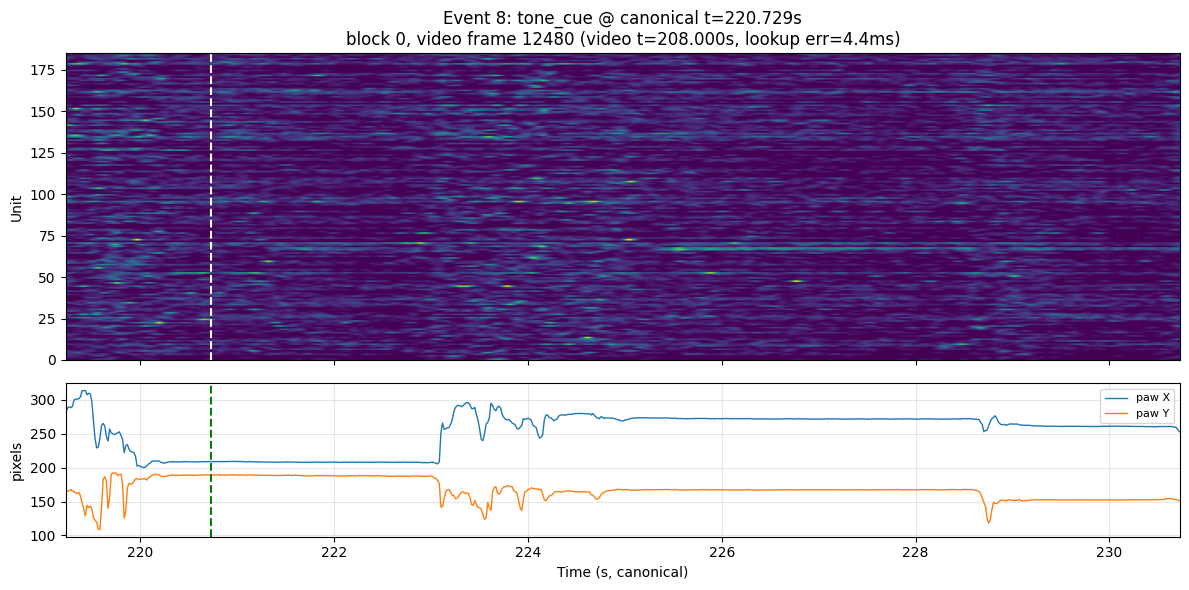


===== CELL G COMPLETE =====



In [94]:
# ============================================================
# CELL G — PERI-EVENT DIAGNOSTIC (PORTABLE)
# ============================================================
# For each event time on a chosen behavioral pin:
#   - shows firing-rate heatmap windowed around the event
#   - overlays DLC trace(s) for selected bodyparts
#   - marks the event with a vertical line
#   - PRINTS canonical time, video frame, and video time
#     so events can be cross-referenced in Fiji/VLC
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("\n===== CELL G — PERI-EVENT DIAGNOSTIC =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
EVENT_PIN       = 4              # 6 = reach, 4 = tone, 3 = motor, etc.
PLOT_BODYPARTS  = ["paw"]
WIN_PRE         = 1.5            # seconds before event
WIN_POST        = 10.0           # seconds after event
MAX_EVENTS_PLOT = 8
ONE_PER_TRIAL   = False          # collapse multi-events per trial to first
TRIAL_PIN       = 4              # trial reference for "one per trial"
VIDEO_FPS       = 60.0           # for video time-from-frame conversion
# ------------------------------------------------------------

if "analysis_folder" not in globals():
    raise RuntimeError("Set analysis_folder.")

with open(analysis_folder / "metadata" / "session.json") as f:
    session = json.load(f)
pin_labels = session["pin_labels"]

# ------------------------------------------------------------
# HELPER: canonical time → video frame number (per block)
# ------------------------------------------------------------
# Each block has its own frame_canonical_times array — element i
# is the canonical time of saved frame i (= MP4 frame i, = DLC row i).
# To go canonical→video, find the saved frame whose canonical time
# is closest to the event. This automatically handles per-session
# offsets (NI-to-camera delay) without needing a stored constant.
# ------------------------------------------------------------

# Pre-load per-block frame canonical times for lookups
block_frame_times = {}
for blk in session["blocks"]:
    b = blk["block_index"]
    block_frame_times[b] = np.load(blk["frame_canonical_times_path"])

def canonical_to_video(t_canonical):
    """Return (block_index, video_frame_number, video_time_s, lookup_error_s).

    video_frame_number = MP4 row that DLC sees as row N
    video_time_s       = seconds from start of MP4 (= frame / fps)
    lookup_error_s     = |canonical time of returned frame - requested t|.
                         Small (< ~17 ms) if the event falls during a saved
                         frame. Larger if the event is in a dropped-frame
                         window — in that case the returned frame is the
                         nearest neighbor, and Fiji will show a frame off
                         by lookup_error_s from the real event.
    Returns (None, None, None, None) if the event is outside all blocks.
    """
    for b, frame_t in block_frame_times.items():
        if frame_t[0] <= t_canonical <= frame_t[-1]:
            # bisect for nearest frame
            idx = np.searchsorted(frame_t, t_canonical)
            # check neighbor on the left in case it's closer
            candidates = []
            if idx < len(frame_t):
                candidates.append(idx)
            if idx > 0:
                candidates.append(idx - 1)
            best = min(candidates, key=lambda i: abs(frame_t[i] - t_canonical))
            err = abs(frame_t[best] - t_canonical)
            video_time = best / VIDEO_FPS
            return b, int(best), float(video_time), float(err)
    return None, None, None, None

# ------------------------------------------------------------
# LOAD EVENT TIMES
# ------------------------------------------------------------
ttls_dir = analysis_folder / "ttls"
event_times = np.load(ttls_dir / f"TTL_Pin_{EVENT_PIN}.npy")
event_label = pin_labels.get(str(EVENT_PIN), f"pin {EVENT_PIN}")
print(f"Event pin {EVENT_PIN} ({event_label}): {len(event_times)} TTLs")

if ONE_PER_TRIAL:
    trial_times = np.load(ttls_dir / f"TTL_Pin_{TRIAL_PIN}.npy")
    kept = []
    for ts in trial_times:
        idx = np.searchsorted(event_times, ts)
        if idx < len(event_times) and event_times[idx] - ts < 25:
            kept.append(event_times[idx])
    event_times = np.array(kept)
    print(f"After 'first per trial' filter: {len(event_times)} events")

event_times = event_times[:MAX_EVENTS_PLOT]

# ------------------------------------------------------------
# PRINT REFERENCE TABLE (BEFORE PLOTTING)
# ------------------------------------------------------------
print(f"\n===== EVENT REFERENCE TABLE =====")
print(f"{'#':>3} | {'canonical (s)':>14} | {'block':>5} | "
      f"{'video frame':>11} | {'video time (s)':>14} | {'lookup err (ms)':>15}")
print("-" * 80)
for i, t_evt in enumerate(event_times):
    b, vframe, vtime, err = canonical_to_video(t_evt)
    if b is None:
        print(f"{i+1:>3} | {t_evt:>14.3f} | {'OOB':>5} | "
              f"{'—':>11} | {'—':>14} | {'—':>15}")
    else:
        flag = " ⚠ in drop?" if err is not None and err > 0.030 else ""
        print(f"{i+1:>3} | {t_evt:>14.3f} | {b:>5} | "
              f"{vframe:>11} | {vtime:>14.3f} | {err*1000:>15.1f}{flag}")
print()

# ------------------------------------------------------------
# LOAD PHYSIOLOGY + DLC
# ------------------------------------------------------------
centers     = np.load(analysis_folder / "qc" / "centers.npy")
rate_matrix = np.load(analysis_folder / "qc" / "rate_matrix.npy")
good_units  = np.load(analysis_folder / "qc" / "good_units.npy")

dlc = np.load(analysis_folder / "dlc_alignment" / "full_session_dlc.npz")
dlc_t = dlc["canonical_time"]

# ------------------------------------------------------------
# PLOT EACH EVENT
# ------------------------------------------------------------
for i, t_evt in enumerate(event_times):
    t0, t1 = t_evt - WIN_PRE, t_evt + WIN_POST
    mask_fr  = (centers >= t0) & (centers <= t1)
    mask_dlc = (dlc_t   >= t0) & (dlc_t   <= t1)

    b, vframe, vtime, err = canonical_to_video(t_evt)
    if b is not None:
        video_str = (f"block {b}, video frame {vframe} "
                     f"(video t={vtime:.3f}s, lookup err={err*1000:.1f}ms)")
    else:
        video_str = "outside any block"

    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True,
                             gridspec_kw={"height_ratios": [2, 1]})

    # Firing rate
    ax = axes[0]
    ax.imshow(rate_matrix[:, mask_fr], aspect="auto",
              extent=[t0, t1, 0, len(good_units)], origin="lower")
    ax.axvline(t_evt, color="white", linestyle="--", lw=1.5)
    ax.set_ylabel("Unit")
    ax.set_title(f"Event {i+1}: {event_label} @ canonical t={t_evt:.3f}s\n"
                 f"{video_str}")

    # DLC
    ax = axes[1]
    for bp in PLOT_BODYPARTS:
        if f"{bp}_x" not in dlc.files:
            continue
        ax.plot(dlc_t[mask_dlc], dlc[f"{bp}_x"][mask_dlc], lw=1.0, label=f"{bp} X")
        ax.plot(dlc_t[mask_dlc], dlc[f"{bp}_y"][mask_dlc], lw=1.0, label=f"{bp} Y")
    ax.axvline(t_evt, color="green", linestyle="--", lw=1.5)
    ax.set_xlabel("Time (s, canonical)")
    ax.set_ylabel("pixels")
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

print("\n===== CELL G COMPLETE =====\n")


===== CELL H — UNIT MODULATION + LATENCY SORT =====
Aligning to: tone_cue (pin 4), 48 events
Computing PSTHs for 185 units × 48 events × 300 bins...

Modulated units (|z|>2.5 for ≥60 ms in 0.0–2.0s post-event): 150 / 185


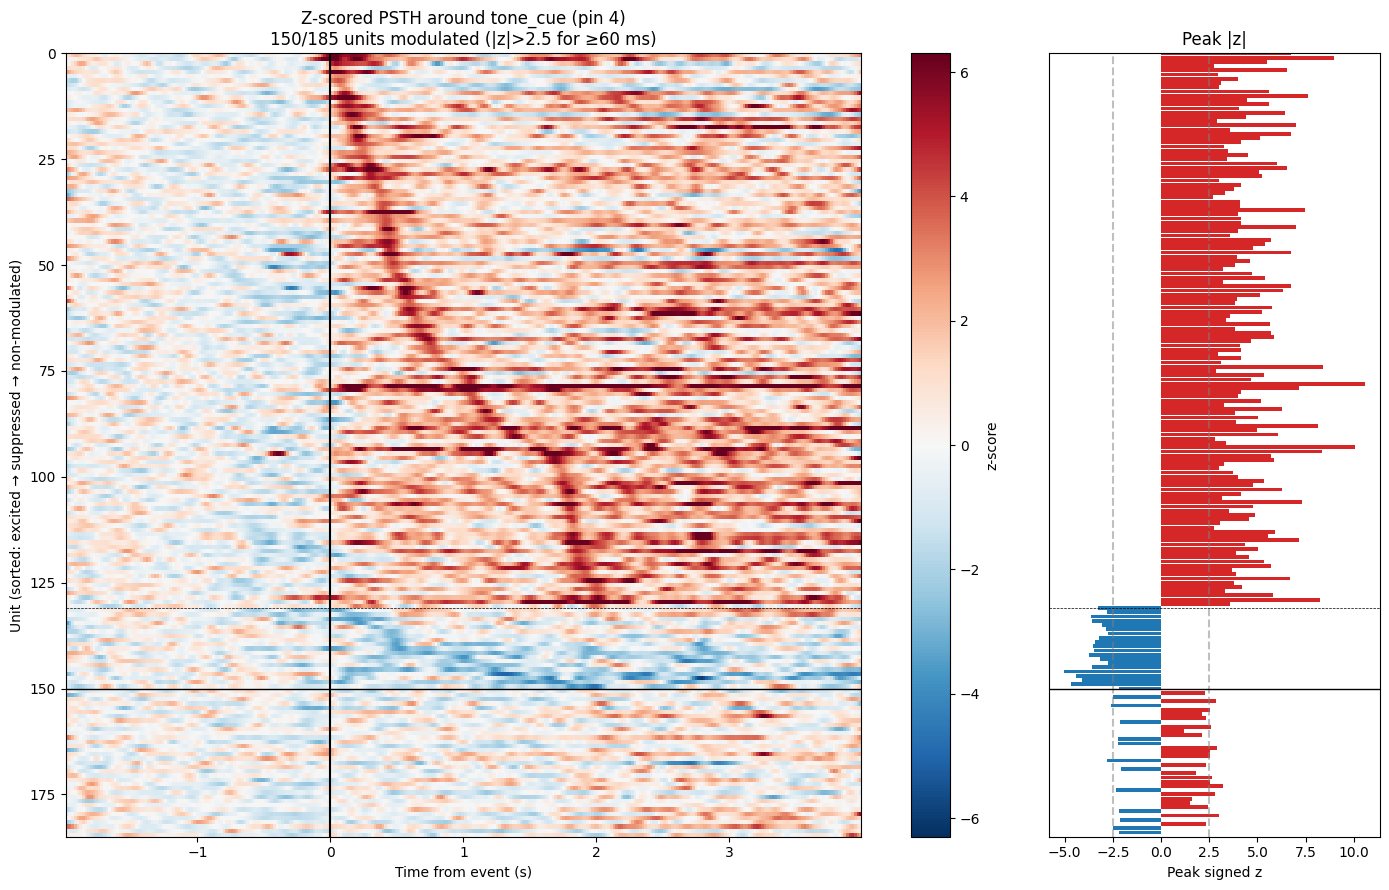


Saved → G:\Kevin\2026-03-09_14-29-25\Record Node 114\2026-03-09_14-29-25_experiment2_recording1_analysis\qc\modulation_pin4_tone_cue.png
Saved arrays → G:\Kevin\2026-03-09_14-29-25\Record Node 114\2026-03-09_14-29-25_experiment2_recording1_analysis\qc\modulation_pin4_tone_cue_arrays.npz

===== CELL H COMPLETE =====



In [95]:
# ============================================================
# CELL H — UNIT MODULATION DETECTION + LATENCY SORT (PORTABLE)
# ============================================================
# For each good unit, build a peri-event PSTH around the chosen
# TTL pin. Z-score against a pre-event baseline, flag units that
# cross a threshold, sort by peak latency, plot as heatmap.
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import gaussian_filter1d

print("\n===== CELL H — UNIT MODULATION + LATENCY SORT =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
EVENT_PIN          = 4          # 4 = tone, 3 = motor (use [0::2] for expose),
                                # 6 = reach, 7 = button
EVENT_LABEL_FOR_3  = None       # if EVENT_PIN==3, set to "expose" or "retract"
                                # (uses [0::2] or [1::2])
WIN_PRE            = 2.0        # seconds before event (for plotting and baseline)
WIN_POST           = 4.0        # seconds after event
BASELINE_WIN       = (-2.0, -0.5)  # baseline window (relative to event) for z-scoring
RESPONSE_WIN       = ( 0.0, 2.0)   # window in which to look for modulation
BIN_SIZE           = 0.020      # seconds (20 ms)
SMOOTH_SIGMA_BINS  = 2          # Gaussian smoothing, in bins (40 ms σ for 20 ms bins)
Z_THRESHOLD        = 2.5        # |z| crossing threshold for "modulated"
MIN_CONSECUTIVE_MS = 60         # must be |z|>threshold for at least this long
ONE_PER_TRIAL      = False
TRIAL_PIN          = 4
# ------------------------------------------------------------

if "analysis_folder" not in globals():
    raise RuntimeError("Set analysis_folder.")

with open(analysis_folder / "metadata" / "session.json") as f:
    session = json.load(f)
pin_labels = session["pin_labels"]
event_label = pin_labels.get(str(EVENT_PIN), f"pin {EVENT_PIN}")

# ------------------------------------------------------------
# LOAD EVENT TIMES
# ------------------------------------------------------------
ttls_dir = analysis_folder / "ttls"
event_times = np.load(ttls_dir / f"TTL_Pin_{EVENT_PIN}.npy")
if EVENT_PIN == 3 and EVENT_LABEL_FOR_3 is not None:
    if EVENT_LABEL_FOR_3 == "expose":
        event_times = event_times[0::2]
        event_label = "pellet_expose"
    elif EVENT_LABEL_FOR_3 == "retract":
        event_times = event_times[1::2]
        event_label = "pellet_retract"
    else:
        raise ValueError("EVENT_LABEL_FOR_3 must be 'expose' or 'retract'")

if ONE_PER_TRIAL:
    trial_times = np.load(ttls_dir / f"TTL_Pin_{TRIAL_PIN}.npy")
    kept = []
    for ts in trial_times:
        idx = np.searchsorted(event_times, ts)
        if idx < len(event_times) and event_times[idx] - ts < 25:
            kept.append(event_times[idx])
    event_times = np.array(kept)

print(f"Aligning to: {event_label} (pin {EVENT_PIN}), {len(event_times)} events")

# ------------------------------------------------------------
# BIN EDGES (in PERI-EVENT TIME, not canonical)
# ------------------------------------------------------------
edges = np.arange(-WIN_PRE, WIN_POST + BIN_SIZE, BIN_SIZE)
centers = edges[:-1] + BIN_SIZE / 2
n_bins = len(centers)

baseline_mask = (centers >= BASELINE_WIN[0]) & (centers < BASELINE_WIN[1])
response_mask = (centers >= RESPONSE_WIN[0]) & (centers < RESPONSE_WIN[1])

# ------------------------------------------------------------
# COMPUTE PSTH PER UNIT
# ------------------------------------------------------------
good_units = np.load(analysis_folder / "qc" / "good_units.npy")
spikes_dir = analysis_folder / "spikes"

psth        = np.zeros((len(good_units), n_bins), dtype=np.float64)  # mean rate
psth_per_trial = np.zeros((len(good_units), len(event_times), n_bins))

print(f"Computing PSTHs for {len(good_units)} units × {len(event_times)} events × {n_bins} bins...")

for u_i, unit in enumerate(good_units):
    spk = np.load(spikes_dir / f"unit_{unit}.npy")
    for e_i, t_evt in enumerate(event_times):
        # spikes in the peri-event window, expressed as time-from-event
        rel = spk[(spk >= t_evt - WIN_PRE) & (spk < t_evt + WIN_POST)] - t_evt
        h, _ = np.histogram(rel, bins=edges)
        psth_per_trial[u_i, e_i] = h / BIN_SIZE  # convert to Hz

# trial-averaged PSTH per unit
psth = psth_per_trial.mean(axis=1)

# smooth
psth_smooth = gaussian_filter1d(psth, sigma=SMOOTH_SIGMA_BINS, axis=1)

# ------------------------------------------------------------
# Z-SCORE EACH UNIT AGAINST ITS OWN BASELINE
# ------------------------------------------------------------
baseline_mean = psth_smooth[:, baseline_mask].mean(axis=1, keepdims=True)
baseline_std  = psth_smooth[:, baseline_mask].std (axis=1, keepdims=True)
baseline_std[baseline_std < 0.5] = 0.5   # floor to avoid div-by-near-zero
                                          # for very quiet baselines (0.5 Hz)

z = (psth_smooth - baseline_mean) / baseline_std   # (n_units, n_bins)

# ------------------------------------------------------------
# MODULATION DETECTION
# ------------------------------------------------------------
min_consec_bins = int(np.ceil(MIN_CONSECUTIVE_MS / 1000.0 / BIN_SIZE))
z_response = z[:, response_mask]

def has_consecutive_crossing(z_row, thresh, min_consec):
    """True if z_row has min_consec consecutive bins with |z|>thresh of same sign."""
    pos = z_row > thresh
    neg = z_row < -thresh
    # run-length detection
    for arr in (pos, neg):
        # find runs of True
        if not arr.any():
            continue
        # quick run-length: pad with False, find rising/falling edges
        padded = np.concatenate([[False], arr, [False]])
        diffs = np.diff(padded.astype(int))
        starts = np.where(diffs == 1)[0]
        ends   = np.where(diffs == -1)[0]
        if (ends - starts).max() >= min_consec:
            return True
    return False

modulated = np.array([
    has_consecutive_crossing(z_response[i], Z_THRESHOLD, min_consec_bins)
    for i in range(len(good_units))
])

n_modulated = int(modulated.sum())
print(f"\nModulated units (|z|>{Z_THRESHOLD} for ≥{MIN_CONSECUTIVE_MS} ms in "
      f"{RESPONSE_WIN[0]}–{RESPONSE_WIN[1]}s post-event): "
      f"{n_modulated} / {len(good_units)}")

# ------------------------------------------------------------
# LATENCY = time of peak signed z within response window
# ------------------------------------------------------------
response_centers = centers[response_mask]
# argmax of absolute z, but keep the sign
peak_idx  = np.argmax(np.abs(z_response), axis=1)
peak_lat  = response_centers[peak_idx]                        # signed latency
peak_z    = z_response[np.arange(len(good_units)), peak_idx]  # signed magnitude

# Among modulated units, sort by latency (excited first, then suppressed,
# each sorted by peak time)
mod_idx       = np.where(modulated)[0]
mod_peak_lat  = peak_lat[mod_idx]
mod_peak_z    = peak_z[mod_idx]

# Sort: excited (peak_z>0) by ascending latency, then suppressed (peak_z<0) by ascending latency
excited_mask  = mod_peak_z > 0
sup_mask      = ~excited_mask

excited_order = mod_idx[excited_mask][np.argsort(mod_peak_lat[excited_mask])]
suppressed_order = mod_idx[sup_mask][np.argsort(mod_peak_lat[sup_mask])]
sorted_mod_idx = np.concatenate([excited_order, suppressed_order])

# Non-modulated units at the bottom, unsorted
non_mod_idx = np.where(~modulated)[0]
full_sort_idx = np.concatenate([sorted_mod_idx, non_mod_idx])

# ------------------------------------------------------------
# PLOT: SORTED Z-SCORE HEATMAP
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 9),
                          gridspec_kw={"width_ratios": [3, 1]})

ax = axes[0]
vmax = max(3.0, np.percentile(np.abs(z), 99))
im = ax.imshow(z[full_sort_idx], aspect="auto",
               extent=[centers[0], centers[-1], len(good_units), 0],
               cmap="RdBu_r", vmin=-vmax, vmax=vmax,
               interpolation="nearest")
ax.axvline(0, color="black", lw=1.5)
ax.axhline(len(excited_order), color="black", lw=0.5, linestyle="--")
ax.axhline(len(sorted_mod_idx), color="black", lw=1.0)
ax.set_xlabel("Time from event (s)")
ax.set_ylabel("Unit (sorted: excited → suppressed → non-modulated)")
ax.set_title(f"Z-scored PSTH around {event_label} (pin {EVENT_PIN})\n"
             f"{n_modulated}/{len(good_units)} units modulated "
             f"(|z|>{Z_THRESHOLD} for ≥{MIN_CONSECUTIVE_MS} ms)")
plt.colorbar(im, ax=ax, label="z-score")

# Side panel: signed peak z for each unit (in same sort order)
ax = axes[1]
y = np.arange(len(good_units))
peak_z_sorted = peak_z[full_sort_idx]
colors = np.where(peak_z_sorted > 0, "C3", "C0")
ax.barh(y, peak_z_sorted, color=colors, height=0.9)
ax.axvline(Z_THRESHOLD, color="gray", linestyle="--", alpha=0.5)
ax.axvline(-Z_THRESHOLD, color="gray", linestyle="--", alpha=0.5)
ax.axhline(len(excited_order), color="black", lw=0.5, linestyle="--")
ax.axhline(len(sorted_mod_idx), color="black", lw=1.0)
ax.set_ylim(len(good_units), 0)
ax.set_xlabel("Peak signed z")
ax.set_yticks([])
ax.set_title("Peak |z|")

plt.tight_layout()

# Save
out_dir = analysis_folder / "qc"
out_path = out_dir / f"modulation_pin{EVENT_PIN}_{event_label}.png"
i = 1
while out_path.exists():
    out_path = out_dir / f"modulation_pin{EVENT_PIN}_{event_label}_{i}.png"
    i += 1
fig.savefig(out_path, dpi=200)
plt.show()
print(f"\nSaved → {out_path}")

# ------------------------------------------------------------
# SAVE RESULTS TO DISK
# ------------------------------------------------------------
results = {
    "event_pin": int(EVENT_PIN),
    "event_label": event_label,
    "n_events": int(len(event_times)),
    "bin_size_s": float(BIN_SIZE),
    "win_pre_s":  float(WIN_PRE),
    "win_post_s": float(WIN_POST),
    "baseline_win_s": list(BASELINE_WIN),
    "response_win_s": list(RESPONSE_WIN),
    "z_threshold": float(Z_THRESHOLD),
    "min_consecutive_ms": float(MIN_CONSECUTIVE_MS),
    "n_units": int(len(good_units)),
    "n_modulated": int(n_modulated),
}
results_path = out_dir / f"modulation_pin{EVENT_PIN}_{event_label}_summary.json"
with open(results_path, "w") as f:
    json.dump(results, f, indent=2)

# Save per-unit arrays
np.savez(out_dir / f"modulation_pin{EVENT_PIN}_{event_label}_arrays.npz",
         good_units=good_units,
         psth_smooth=psth_smooth,
         z=z,
         modulated=modulated,
         peak_latency=peak_lat,
         peak_z=peak_z,
         sort_order=full_sort_idx,
         centers=centers)
print(f"Saved arrays → {out_dir / f'modulation_pin{EVENT_PIN}_{event_label}_arrays.npz'}")

print("\n===== CELL H COMPLETE =====\n")


===== CELL I — SHUFFLED CONTROLS =====
Real events (tone_cue, pin 4): 48
Loaded spike times for 185 units

Computing real-data PSTHs...
Real data: 150 / 185 modulated (81.1%)

--- Test 1: shuffling event times (100 iterations) ---
  10/100 done. Running mean modulated (shuffled): 99.4
  20/100 done. Running mean modulated (shuffled): 98.0
  30/100 done. Running mean modulated (shuffled): 95.2
  40/100 done. Running mean modulated (shuffled): 95.2
  50/100 done. Running mean modulated (shuffled): 93.8
  60/100 done. Running mean modulated (shuffled): 93.2
  70/100 done. Running mean modulated (shuffled): 93.8
  80/100 done. Running mean modulated (shuffled): 93.9
  90/100 done. Running mean modulated (shuffled): 94.3
  100/100 done. Running mean modulated (shuffled): 94.4

Test 1 results:
  Real:           150 modulated units
  Shuffled mean:  94.4 ± 12.6
  Shuffled 95th:  118
  Real / shuffled-mean ratio: 1.6×
  p-value (real ≥ shuffled):  0.0000

--- Test 2: shuffling PSTH bins withi

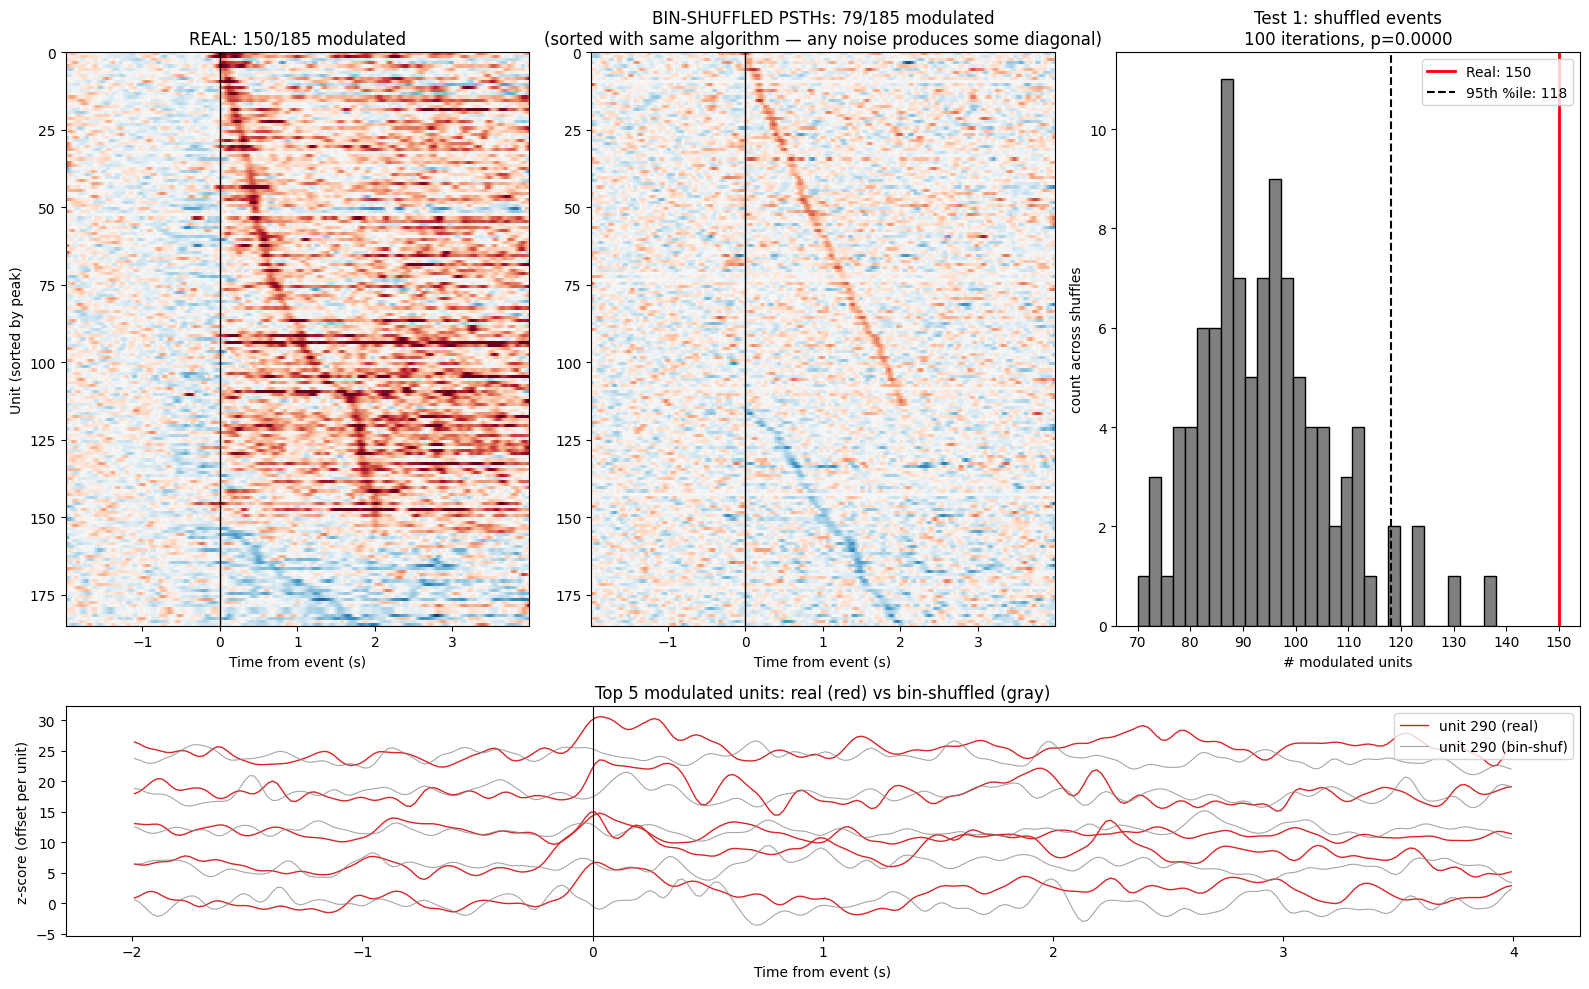


Saved → G:\Kevin\2026-03-09_14-29-25\Record Node 114\2026-03-09_14-29-25_experiment2_recording1_analysis\qc\falsification_pin4_tone_cue.png

===== INTERPRETATION =====

Test 1 (shuffled event times):
  ~ MARGINAL. Real exceeds shuffled (p=0.0000) but ratio (1.6×) is modest. Some signal, but weaker than the plot suggests.

Test 2 (bin-shuffled PSTHs):
  ✗ FAILED. Bin-shuffled PSTHs (79) modulate almost as much as real (150). The diagonal is largely a sorting artifact (any data sorted by argmax forms a diagonal). STOP and reconsider.

===== CELL I COMPLETE =====



In [96]:
# ============================================================
# CELL I — FALSIFICATION TESTS: SHUFFLED CONTROLS
# ============================================================
# Two independent null distributions to test whether the
# modulation pattern in Cell H is real signal or analysis artifact.
#
# Test 1: SHUFFLED EVENT TIMES
#   Replace the 48 real event times with 48 random times drawn
#   from the recording, run the full Cell H analysis, count
#   modulated units. Repeat N_SHUFFLES times.
#   → Tests: is the population response time-locked to the actual
#     events, or would *any* set of events produce this pattern?
#
# Test 2: PER-BIN SHUFFLED PSTHs
#   Take the real PSTHs and shuffle each unit's bins independently.
#   Re-detect modulation and re-sort. The resulting heatmap will
#   look superficially similar (any sorted-by-argmax data forms a
#   diagonal) but the # of "modulated" units and the strength of
#   the diagonal should be much lower.
#   → Tests: is the sort doing the work, or is there real structure?
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import gaussian_filter1d

print("\n===== CELL I — SHUFFLED CONTROLS =====")

# ------------------------------------------------------------
# USER EDIT — must match Cell H parameters exactly
# ------------------------------------------------------------
EVENT_PIN          = 4
WIN_PRE            = 2.0
WIN_POST           = 4.0
BASELINE_WIN       = (-2.0, -0.5)
RESPONSE_WIN       = ( 0.0,  2.0)
BIN_SIZE           = 0.020
SMOOTH_SIGMA_BINS  = 2
Z_THRESHOLD        = 2.5
MIN_CONSECUTIVE_MS = 60
N_SHUFFLES         = 100      # 100 is enough for a strong test; 1000 for publication
RANDOM_SEED        = 42
# ------------------------------------------------------------

if "analysis_folder" not in globals():
    raise RuntimeError("Set analysis_folder.")

with open(analysis_folder / "metadata" / "session.json") as f:
    session = json.load(f)
pin_labels = session["pin_labels"]
event_label = pin_labels.get(str(EVENT_PIN), f"pin {EVENT_PIN}")
recording_duration = session["recording_duration_s"]

# ------------------------------------------------------------
# LOAD EVENT TIMES + UNITS
# ------------------------------------------------------------
ttls_dir = analysis_folder / "ttls"
real_events = np.load(ttls_dir / f"TTL_Pin_{EVENT_PIN}.npy")
print(f"Real events ({event_label}, pin {EVENT_PIN}): {len(real_events)}")

good_units = np.load(analysis_folder / "qc" / "good_units.npy")
spikes_dir = analysis_folder / "spikes"

# Pre-load all spike trains
all_spikes = {int(u): np.load(spikes_dir / f"unit_{u}.npy") for u in good_units}
print(f"Loaded spike times for {len(good_units)} units")

# ------------------------------------------------------------
# SHARED HELPERS
# ------------------------------------------------------------
edges = np.arange(-WIN_PRE, WIN_POST + BIN_SIZE, BIN_SIZE)
centers = edges[:-1] + BIN_SIZE / 2
n_bins = len(centers)

baseline_mask = (centers >= BASELINE_WIN[0]) & (centers < BASELINE_WIN[1])
response_mask = (centers >= RESPONSE_WIN[0]) & (centers < RESPONSE_WIN[1])
min_consec_bins = int(np.ceil(MIN_CONSECUTIVE_MS / 1000.0 / BIN_SIZE))

def compute_psth_zscore(events):
    """Returns (psth_smooth, z) given a set of event times."""
    psth_per_trial = np.zeros((len(good_units), len(events), n_bins))
    for u_i, u in enumerate(good_units):
        spk = all_spikes[int(u)]
        for e_i, t_evt in enumerate(events):
            rel = spk[(spk >= t_evt - WIN_PRE) & (spk < t_evt + WIN_POST)] - t_evt
            h, _ = np.histogram(rel, bins=edges)
            psth_per_trial[u_i, e_i] = h / BIN_SIZE
    psth = psth_per_trial.mean(axis=1)
    psth_smooth = gaussian_filter1d(psth, sigma=SMOOTH_SIGMA_BINS, axis=1)
    base_mean = psth_smooth[:, baseline_mask].mean(axis=1, keepdims=True)
    base_std  = psth_smooth[:, baseline_mask].std (axis=1, keepdims=True)
    base_std[base_std < 0.5] = 0.5
    z = (psth_smooth - base_mean) / base_std
    return psth_smooth, z

def count_modulated(z):
    """Returns number of units with |z|>thresh for ≥min_consec_bins in response window."""
    z_resp = z[:, response_mask]
    count = 0
    for i in range(z_resp.shape[0]):
        for arr in (z_resp[i] > Z_THRESHOLD, z_resp[i] < -Z_THRESHOLD):
            if not arr.any():
                continue
            padded = np.concatenate([[False], arr, [False]])
            diffs = np.diff(padded.astype(int))
            starts = np.where(diffs ==  1)[0]
            ends   = np.where(diffs == -1)[0]
            if (ends - starts).max() >= min_consec_bins:
                count += 1
                break
    return count

# ------------------------------------------------------------
# REAL DATA — recompute for comparison
# ------------------------------------------------------------
print("\nComputing real-data PSTHs...")
real_psth, real_z = compute_psth_zscore(real_events)
real_n_modulated = count_modulated(real_z)
print(f"Real data: {real_n_modulated} / {len(good_units)} modulated "
      f"({100*real_n_modulated/len(good_units):.1f}%)")

# ============================================================
# TEST 1: SHUFFLED EVENT TIMES
# ============================================================
print(f"\n--- Test 1: shuffling event times ({N_SHUFFLES} iterations) ---")

rng = np.random.default_rng(RANDOM_SEED)

# Constrain shuffled events to leave room for WIN_PRE / WIN_POST
t_min = WIN_PRE + 1.0
t_max = recording_duration - WIN_POST - 1.0

shuffled_n_modulated = np.zeros(N_SHUFFLES, dtype=int)
for s in range(N_SHUFFLES):
    fake_events = rng.uniform(t_min, t_max, size=len(real_events))
    fake_events.sort()
    _, fake_z = compute_psth_zscore(fake_events)
    shuffled_n_modulated[s] = count_modulated(fake_z)
    if (s + 1) % 10 == 0:
        print(f"  {s+1}/{N_SHUFFLES} done. "
              f"Running mean modulated (shuffled): "
              f"{shuffled_n_modulated[:s+1].mean():.1f}")

shuffled_mean = shuffled_n_modulated.mean()
shuffled_std  = shuffled_n_modulated.std()
shuffled_95   = np.percentile(shuffled_n_modulated, 95)
p_value       = (shuffled_n_modulated >= real_n_modulated).sum() / N_SHUFFLES

print(f"\nTest 1 results:")
print(f"  Real:           {real_n_modulated} modulated units")
print(f"  Shuffled mean:  {shuffled_mean:.1f} ± {shuffled_std:.1f}")
print(f"  Shuffled 95th:  {shuffled_95:.0f}")
print(f"  Real / shuffled-mean ratio: {real_n_modulated / max(shuffled_mean, 1):.1f}×")
print(f"  p-value (real ≥ shuffled):  {p_value:.4f}")

# ============================================================
# TEST 2: PER-BIN SHUFFLED PSTHs (sort-order falsification)
# ============================================================
print(f"\n--- Test 2: shuffling PSTH bins within each unit ---")

# Take the real PSTH, shuffle each row's bins independently
shuffled_psth = real_psth.copy()
for i in range(shuffled_psth.shape[0]):
    rng.shuffle(shuffled_psth[i])

# Re-smooth (since smoothing assumed temporal structure)
shuffled_psth_smooth = gaussian_filter1d(shuffled_psth, sigma=SMOOTH_SIGMA_BINS, axis=1)
base_m = shuffled_psth_smooth[:, baseline_mask].mean(axis=1, keepdims=True)
base_s = shuffled_psth_smooth[:, baseline_mask].std (axis=1, keepdims=True)
base_s[base_s < 0.5] = 0.5
shuffled_z = (shuffled_psth_smooth - base_m) / base_s

# Modulation count
binshuf_n_modulated = count_modulated(shuffled_z)
print(f"  Bin-shuffled modulated: {binshuf_n_modulated}")

# Sort by peak latency in response window (same algorithm as Cell H)
def sort_by_peak(z_mat):
    z_resp = z_mat[:, response_mask]
    response_centers = centers[response_mask]
    peak_idx = np.argmax(np.abs(z_resp), axis=1)
    peak_lat = response_centers[peak_idx]
    peak_z   = z_resp[np.arange(z_resp.shape[0]), peak_idx]
    excited  = peak_z > 0
    order    = np.concatenate([
        np.where(excited)[0][np.argsort(peak_lat[excited])],
        np.where(~excited)[0][np.argsort(peak_lat[~excited])],
    ])
    return order

real_order   = sort_by_peak(real_z)
shuf_order   = sort_by_peak(shuffled_z)

# ============================================================
# FIGURE: SIDE-BY-SIDE HEATMAPS + HISTOGRAM
# ============================================================
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 3, height_ratios=[2.5, 1])

vmax = max(3.0, np.percentile(np.abs(real_z), 99))

ax = fig.add_subplot(gs[0, 0])
ax.imshow(real_z[real_order], aspect="auto",
          extent=[centers[0], centers[-1], len(good_units), 0],
          cmap="RdBu_r", vmin=-vmax, vmax=vmax, interpolation="nearest")
ax.axvline(0, color="black", lw=1.0)
ax.set_xlabel("Time from event (s)")
ax.set_ylabel("Unit (sorted by peak)")
ax.set_title(f"REAL: {real_n_modulated}/{len(good_units)} modulated")

ax = fig.add_subplot(gs[0, 1])
ax.imshow(shuffled_z[shuf_order], aspect="auto",
          extent=[centers[0], centers[-1], len(good_units), 0],
          cmap="RdBu_r", vmin=-vmax, vmax=vmax, interpolation="nearest")
ax.axvline(0, color="black", lw=1.0)
ax.set_xlabel("Time from event (s)")
ax.set_title(f"BIN-SHUFFLED PSTHs: {binshuf_n_modulated}/{len(good_units)} modulated\n"
             "(sorted with same algorithm — any noise produces some diagonal)")

# Histogram of shuffled-events modulated counts
ax = fig.add_subplot(gs[0, 2])
ax.hist(shuffled_n_modulated, bins=30, color="gray", edgecolor="black")
ax.axvline(real_n_modulated, color="red", lw=2,
           label=f"Real: {real_n_modulated}")
ax.axvline(shuffled_95, color="black", linestyle="--",
           label=f"95th %ile: {shuffled_95:.0f}")
ax.set_xlabel("# modulated units")
ax.set_ylabel("count across shuffles")
ax.set_title(f"Test 1: shuffled events\n{N_SHUFFLES} iterations, p={p_value:.4f}")
ax.legend()

# Bottom row: example PSTHs to compare
ax = fig.add_subplot(gs[1, :])
# Show real vs shuffled for a few top-modulated units
top_units_idx = real_order[:5]
for k, u_i in enumerate(top_units_idx):
    ax.plot(centers, real_z[u_i] + k * 6, color="C3", lw=1.0,
            label=f"unit {good_units[u_i]} (real)" if k == 0 else None)
    ax.plot(centers, shuffled_z[u_i] + k * 6, color="gray", lw=0.8, alpha=0.7,
            label=f"unit {good_units[u_i]} (bin-shuf)" if k == 0 else None)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Time from event (s)")
ax.set_ylabel("z-score (offset per unit)")
ax.set_title("Top 5 modulated units: real (red) vs bin-shuffled (gray)")
ax.legend(loc="upper right")

plt.tight_layout()

out_dir = analysis_folder / "qc"
out_path = out_dir / f"falsification_pin{EVENT_PIN}_{event_label}.png"
i = 1
while out_path.exists():
    out_path = out_dir / f"falsification_pin{EVENT_PIN}_{event_label}_{i}.png"
    i += 1
fig.savefig(out_path, dpi=200)
plt.show()
print(f"\nSaved → {out_path}")

# ============================================================
# INTERPRETATION
# ============================================================
print("\n===== INTERPRETATION =====")

print(f"\nTest 1 (shuffled event times):")
if p_value < 0.01 and real_n_modulated > shuffled_mean * 3:
    print(f"  ✓ PASSED. Real modulation count ({real_n_modulated}) is "
          f"{real_n_modulated/shuffled_mean:.1f}× the shuffled mean. "
          f"The temporal structure is locked to actual events.")
elif p_value < 0.05:
    print(f"  ~ MARGINAL. Real exceeds shuffled (p={p_value:.4f}) but ratio "
          f"({real_n_modulated/max(shuffled_mean,1):.1f}×) is modest. "
          f"Some signal, but weaker than the plot suggests.")
else:
    print(f"  ✗ FAILED. Shuffled events produce similar modulation counts. "
          f"The diagonal in your Cell H plot is likely an analysis artifact, "
          f"NOT real time-locked response. STOP and investigate.")

print(f"\nTest 2 (bin-shuffled PSTHs):")
if real_n_modulated > binshuf_n_modulated * 3:
    print(f"  ✓ PASSED. Real ({real_n_modulated}) vs bin-shuffled "
          f"({binshuf_n_modulated}): real shows much more modulation than "
          f"randomly-permuted bins. Real structure is in the temporal "
          f"pattern, not just in the sorting.")
else:
    print(f"  ✗ FAILED. Bin-shuffled PSTHs ({binshuf_n_modulated}) modulate "
          f"almost as much as real ({real_n_modulated}). The diagonal is "
          f"largely a sorting artifact (any data sorted by argmax forms a "
          f"diagonal). STOP and reconsider.")

print("\n===== CELL I COMPLETE =====\n")


===== CELL J — FAST-RESPONDER ARTIFACT CHECK =====
Inspecting 10 fastest excited modulated units:
  #1: unit 290  peak latency = 10.0 ms, peak z = 6.72
  #2: unit 346  peak latency = 10.0 ms, peak z = 8.97
  #3: unit 194  peak latency = 30.0 ms, peak z = 5.49
  #4: unit 295  peak latency = 30.0 ms, peak z = 2.75
  #5: unit 429  peak latency = 30.0 ms, peak z = 6.55
  #6: unit 267  peak latency = 50.0 ms, peak z = 2.96
  #7: unit 317  peak latency = 50.0 ms, peak z = 3.99
  #8: unit 414  peak latency = 70.0 ms, peak z = 3.11
  #9: unit 191  peak latency = 110.0 ms, peak z = 2.99
  #10: unit 4  peak latency = 110.0 ms, peak z = 5.59

Fastest peak latency: 10.0 ms
  ✓ OK: ≥10 ms is consistent with biological response latencies.

Loaded templates: shape (437, 61, 384)


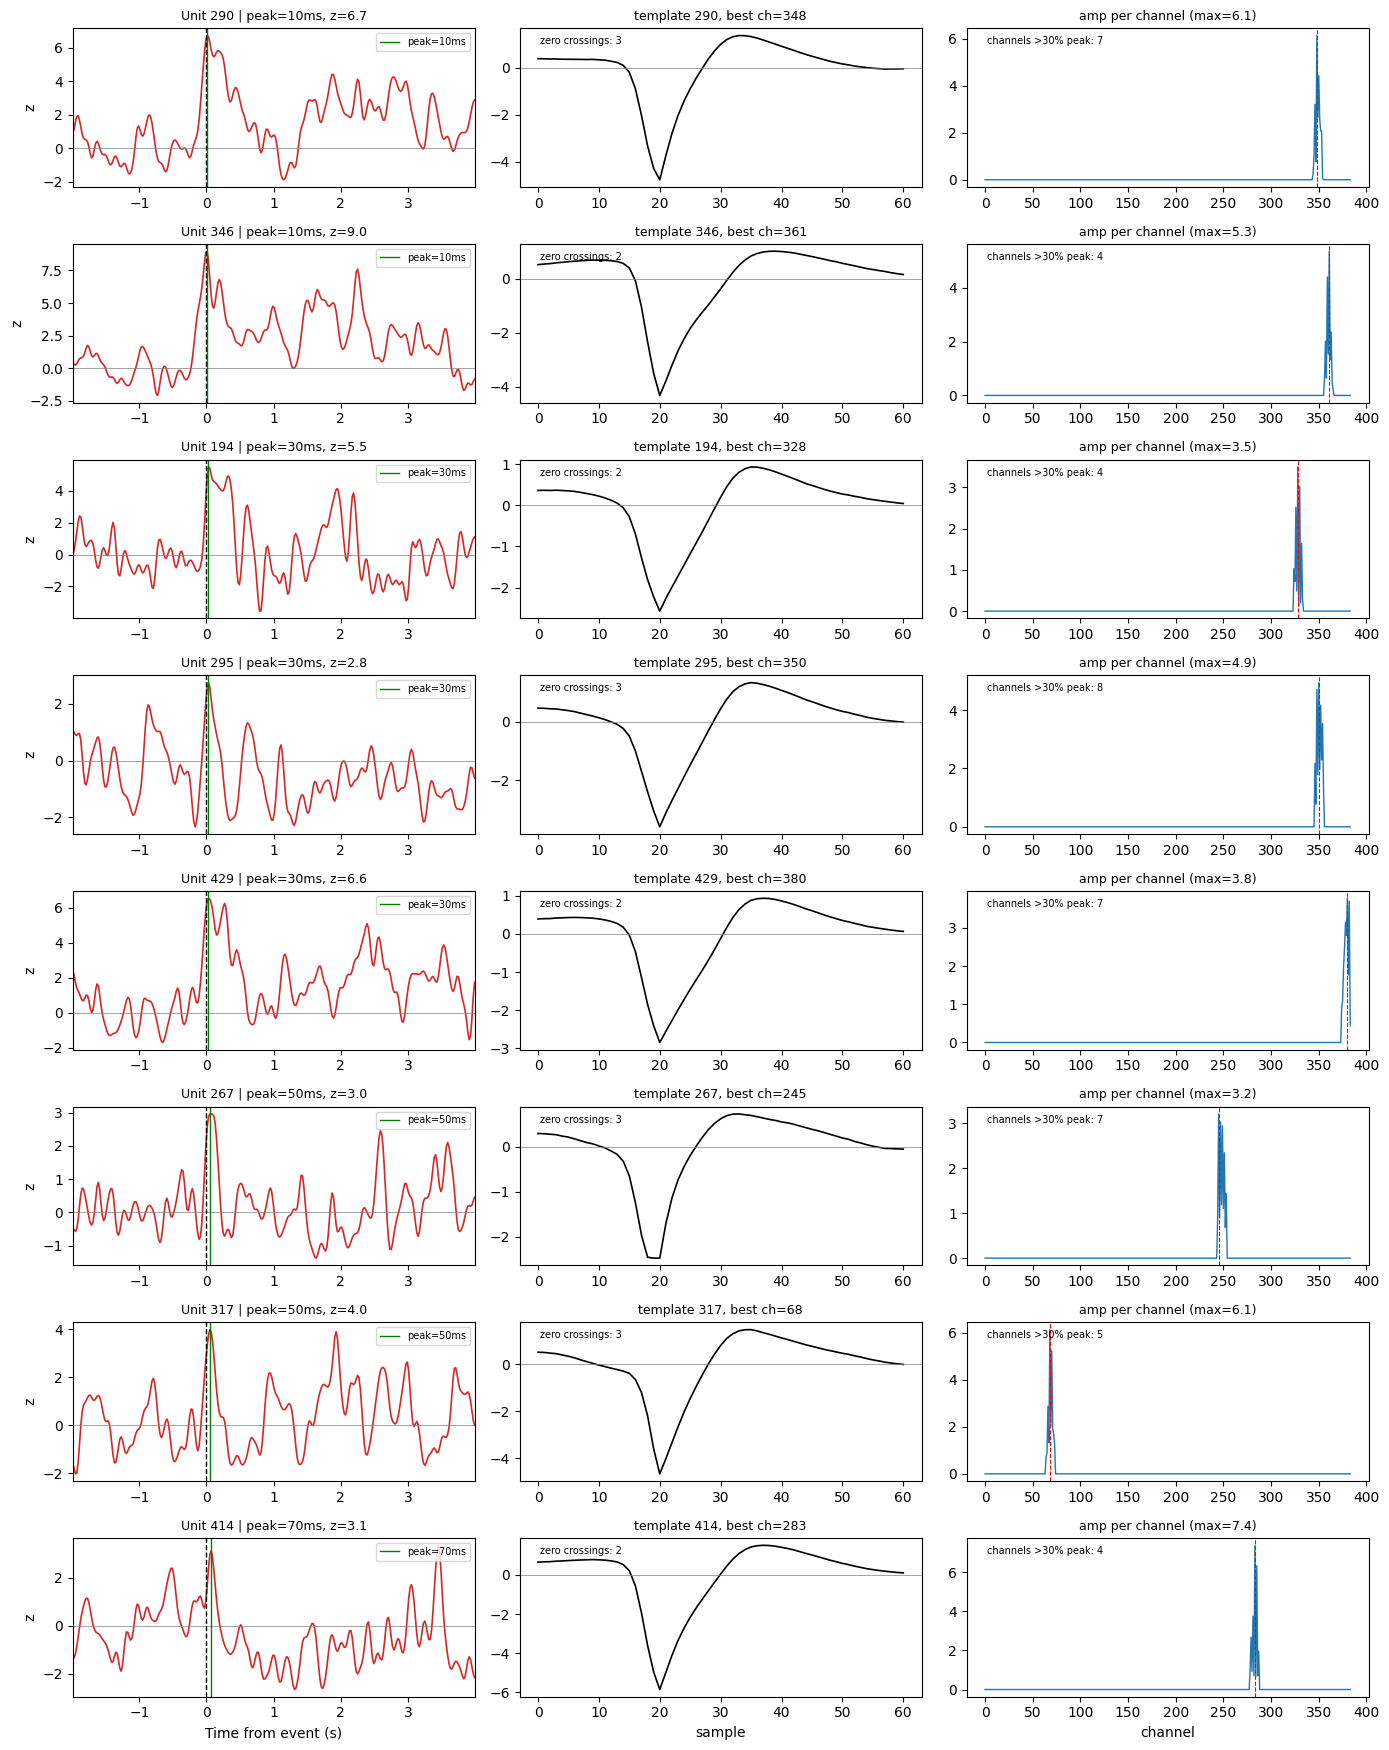


Saved → G:\Kevin\2026-03-09_14-29-25\Record Node 114\2026-03-09_14-29-25_experiment2_recording1_analysis\qc\fast_responder_check_pin4.png

===== INTERPRETATION HEURISTICS =====
For each unit, check:
  • Peak latency: <5 ms is suspicious; 10-50 ms is typical cortical;
    50-500 ms is typical for movement/cognitive responses.
  • Waveform: should be biphasic (~2-4 zero crossings near baseline),
    with peak-to-trough width ~0.3-1.5 ms. Symmetric or many-zero-crossing
    waveforms suggest noise/artifact.
  • Channel spread: real units appear on <~10 channels at >30% of peak.
    Units appearing strongly on >20 channels are likely common-mode
    artifacts contaminating multiple channels.

===== CELL J COMPLETE =====



In [97]:
# ============================================================
# CELL J — FAST-RESPONDER ARTIFACT CHECK
# ============================================================
# Inspects the fastest-peaking units from Cell H for signs of
# electrical / EMF artifact:
#   1. Peak latency — biological cortical responses are
#      typically ≥10-15 ms. Sub-5-ms responses are suspicious.
#   2. Waveform shape — pulls templates from the Kilosort
#      folder for the top-responding units.
#   3. Channel spread — real units live on a few neighboring
#      channels; artifacts often span the entire probe.
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("\n===== CELL J — FAST-RESPONDER ARTIFACT CHECK =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
EVENT_PIN     = 4
PROBEA_PATH   = r"G:\Kevin\2026-03-09_14-29-25\Record Node 114\experiment2\recording1\continuous\Neuropix-PXI-107.ProbeA\kilosort4"
N_TOP_INSPECT = 10        # how many fastest-peaking modulated units to examine
# ------------------------------------------------------------

if "analysis_folder" not in globals():
    raise RuntimeError("Set analysis_folder.")

with open(analysis_folder / "metadata" / "session.json") as f:
    session = json.load(f)
pin_labels = session["pin_labels"]
event_label = pin_labels.get(str(EVENT_PIN), f"pin {EVENT_PIN}")

# ------------------------------------------------------------
# LOAD CELL H RESULTS
# ------------------------------------------------------------
arrays_path = analysis_folder / "qc" / f"modulation_pin{EVENT_PIN}_{event_label}_arrays.npz"
if not arrays_path.exists():
    raise FileNotFoundError(f"Run Cell H first. Missing: {arrays_path}")

H = np.load(arrays_path)
good_units    = H["good_units"]
z             = H["z"]
modulated     = H["modulated"]
peak_latency  = H["peak_latency"]
peak_z        = H["peak_z"]
centers       = H["centers"]

# Among modulated EXCITED units, find the fastest-peaking
mod_excited = modulated & (peak_z > 0)
mod_excited_idx = np.where(mod_excited)[0]
order_by_latency = mod_excited_idx[np.argsort(peak_latency[mod_excited_idx])]
top_idx = order_by_latency[:N_TOP_INSPECT]

print(f"Inspecting {len(top_idx)} fastest excited modulated units:")
for rank, ui in enumerate(top_idx):
    print(f"  #{rank+1}: unit {good_units[ui]}  "
          f"peak latency = {peak_latency[ui]*1000:.1f} ms, "
          f"peak z = {peak_z[ui]:.2f}")

# ------------------------------------------------------------
# LATENCY DIAGNOSTIC
# ------------------------------------------------------------
fastest_lat_ms = peak_latency[top_idx[0]] * 1000
print(f"\nFastest peak latency: {fastest_lat_ms:.1f} ms")
if fastest_lat_ms < 5:
    print("  ⚠ SUSPICIOUS: <5 ms is too fast for biological response.")
    print("    Likely candidates: EMF artifact, common-mode noise, "
          "shared spike-sorting template.")
elif fastest_lat_ms < 10:
    print("  ~ BORDERLINE: 5-10 ms is fast but possible for some "
          "subcortical or fast-fiber responses. Check waveforms.")
else:
    print("  ✓ OK: ≥10 ms is consistent with biological response latencies.")

# ------------------------------------------------------------
# LOAD KILOSORT TEMPLATES
# ------------------------------------------------------------
probe_dir = Path(PROBEA_PATH)
try:
    templates = np.load(probe_dir / "templates.npy")
    # templates.shape = (n_templates, n_timepoints, n_channels)
    spike_clusters = np.load(probe_dir / "spike_clusters.npy").flatten()
    spike_templates = np.load(probe_dir / "spike_templates.npy").flatten()
    print(f"\nLoaded templates: shape {templates.shape}")
except FileNotFoundError as e:
    print(f"\nCould not load templates: {e}")
    print("Skipping waveform analysis.")
    templates = None

# ------------------------------------------------------------
# FIGURE: PSTH + waveform + channel-amplitude for each top unit
# ------------------------------------------------------------
n_show = min(len(top_idx), 8)
fig, axes = plt.subplots(n_show, 3, figsize=(14, 2.2 * n_show))
if n_show == 1:
    axes = axes[np.newaxis, :]

for k in range(n_show):
    ui = top_idx[k]
    unit_id = int(good_units[ui])

    # --- (1) PSTH ---
    ax = axes[k, 0]
    ax.plot(centers, z[ui], color="C3", lw=1.2)
    ax.axhline(0, color="gray", lw=0.5)
    ax.axvline(0, color="black", lw=1.0, linestyle="--")
    ax.axvline(peak_latency[ui], color="green", lw=1.0,
               label=f"peak={peak_latency[ui]*1000:.0f}ms")
    ax.set_xlim(centers[0], centers[-1])
    ax.set_ylabel("z")
    if k == n_show - 1:
        ax.set_xlabel("Time from event (s)")
    ax.set_title(f"Unit {unit_id} | peak={peak_latency[ui]*1000:.0f}ms, "
                 f"z={peak_z[ui]:.1f}", fontsize=9)
    ax.legend(fontsize=7, loc="upper right")

    # --- (2) Waveform on best channel ---
    ax = axes[k, 1]
    if templates is not None:
        # Find the most-used template for this cluster
        cluster_spike_templates = spike_templates[spike_clusters == unit_id]
        if len(cluster_spike_templates) == 0:
            ax.text(0.5, 0.5, "no spikes", ha="center", va="center",
                    transform=ax.transAxes)
        else:
            t_id = np.bincount(cluster_spike_templates).argmax()
            wf = templates[t_id]   # (n_timepoints, n_channels)
            # peak-to-peak amplitude per channel
            ch_amp = wf.max(axis=0) - wf.min(axis=0)
            best_ch = int(np.argmax(ch_amp))
            ax.plot(wf[:, best_ch], color="black", lw=1.2)
            ax.set_title(f"template {t_id}, best ch={best_ch}", fontsize=9)
            # rough width estimate
            trace = wf[:, best_ch]
            ax.axhline(0, color="gray", lw=0.5)
            # check if waveform is biphasic
            n_zero_crossings = np.sum(np.diff(np.sign(trace)) != 0)
            ax.text(0.05, 0.95, f"zero crossings: {n_zero_crossings}",
                    transform=ax.transAxes, fontsize=7, va="top")
    else:
        ax.text(0.5, 0.5, "templates not loaded",
                ha="center", va="center", transform=ax.transAxes)
    if k == n_show - 1:
        ax.set_xlabel("sample")

    # --- (3) Amplitude across channels ---
    ax = axes[k, 2]
    if templates is not None and len(cluster_spike_templates) > 0:
        ax.plot(ch_amp, color="C0", lw=1.0)
        ax.set_title(f"amp per channel (max={ch_amp.max():.1f})", fontsize=9)
        ax.axvline(best_ch, color="red", lw=0.8, linestyle="--")
        # count channels with > 30% of peak
        n_strong = int((ch_amp > 0.3 * ch_amp.max()).sum())
        ax.text(0.05, 0.95, f"channels >30% peak: {n_strong}",
                transform=ax.transAxes, fontsize=7, va="top",
                color="red" if n_strong > 20 else "black")
    if k == n_show - 1:
        ax.set_xlabel("channel")

plt.tight_layout()

out_path = analysis_folder / "qc" / f"fast_responder_check_pin{EVENT_PIN}.png"
i = 1
while out_path.exists():
    out_path = analysis_folder / "qc" / f"fast_responder_check_pin{EVENT_PIN}_{i}.png"
    i += 1
fig.savefig(out_path, dpi=200)
plt.show()
print(f"\nSaved → {out_path}")

# ------------------------------------------------------------
# SUMMARY INTERPRETATION
# ------------------------------------------------------------
print("\n===== INTERPRETATION HEURISTICS =====")
print("For each unit, check:")
print("  • Peak latency: <5 ms is suspicious; 10-50 ms is typical cortical;")
print("    50-500 ms is typical for movement/cognitive responses.")
print("  • Waveform: should be biphasic (~2-4 zero crossings near baseline),")
print("    with peak-to-trough width ~0.3-1.5 ms. Symmetric or many-zero-crossing")
print("    waveforms suggest noise/artifact.")
print("  • Channel spread: real units appear on <~10 channels at >30% of peak.")
print("    Units appearing strongly on >20 channels are likely common-mode")
print("    artifacts contaminating multiple channels.")

print("\n===== CELL J COMPLETE =====\n")


===== Multi-Block Timeline Visualization =====
Full-session camera TTLs:   116497
Full-session behavior TTLs: 48

--- Block 0 ---
TTL pulses: 116497
Aligned frames loaded from: G:\Kevin\2026-03-09_14-29-25\Record Node 114\2026-03-09_14-29-25_experiment2_recording1_analysis\camera_alignment\aligned_frames_block0.npy
Start: 12.594 s
End:   1955.354 s

Collected all block timelines.


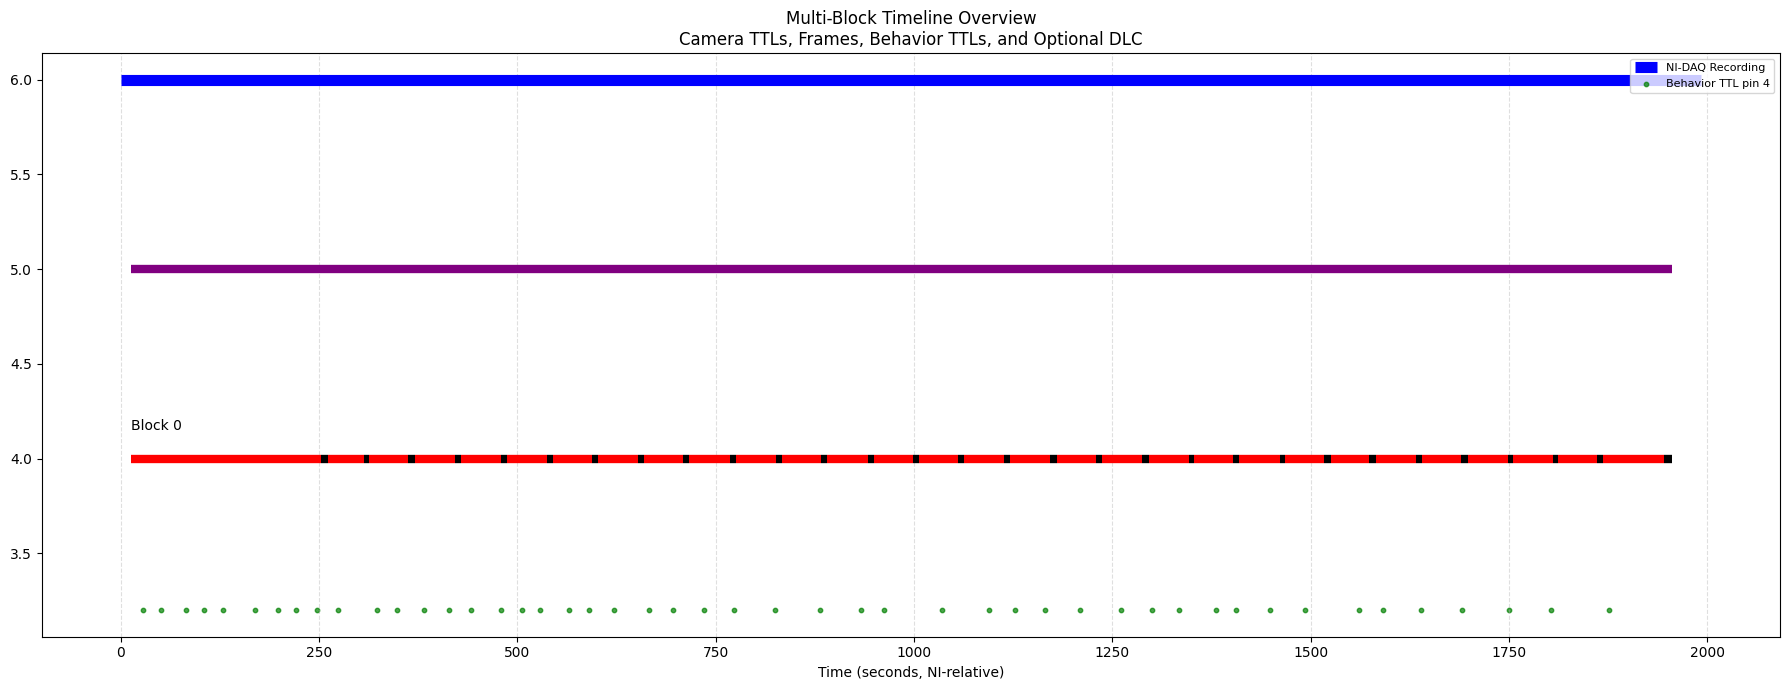


===== MULTI-BLOCK TIMELINE VISUALIZATION COMPLETE =====

Saved timeline figure → G:\Kevin\2026-03-09_14-29-25\Record Node 114\2026-03-09_14-29-25_experiment2_recording1_analysis\camera_alignment\timeline_overview_pin1.png


In [77]:
# ============================================================
# ========== CELL H — MULTI-BLOCK TIMELINE VISUALIZATION =====
# ============================================================

import os
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("\n===== Multi-Block Timeline Visualization =====")

# ------------------------------------------------------------
# SAFETY CHECKS
# ------------------------------------------------------------
required_vars = ["analysis_folder", "session"]
for v in required_vars:
    if v not in globals():
        raise RuntimeError(f"Variable '{v}' is missing. Run previous cells first.")

# ------------------------------------------------------------
# USER INPUT
# ------------------------------------------------------------
CAMERA_TTL_PIN = 1
BEHAVIOR_PIN   = 4          # <--- NEW
PLOT_DLC       = True       # <--- NEW

# ------------------------------------------------------------
# 1. Load full-session TTLs (camera + behavior)
# ------------------------------------------------------------
ttls_dir = analysis_folder / "ttls"

ttl_times_full = np.load(ttls_dir / f"TTL_Pin_{CAMERA_TTL_PIN}.npy")
behavior_ttls  = np.load(ttls_dir / f"TTL_Pin_{BEHAVIOR_PIN}.npy")   # <--- NEW

print(f"Full-session camera TTLs:   {len(ttl_times_full)}")
print(f"Full-session behavior TTLs: {len(behavior_ttls)}")

# Load NI timing metadata
meta_path = analysis_folder / "metadata" / "ttl_metadata.json"
with open(meta_path, "r") as f:
    ttl_meta = json.load(f)

ni_start = ttl_meta["ni_start_time_rel"]   # always 0.0
ni_end   = ttl_meta["ni_end_time_rel"]

# ------------------------------------------------------------
# 2. Collect block timelines
# ------------------------------------------------------------
block_segments = []

for block_index, block in enumerate(session["blocks"]):

    ttl_times_block = np.array(block["ttl_times"])

    aligned_frames_path = Path(block["aligned_frames_path"])
    if not aligned_frames_path.exists():
        raise FileNotFoundError(f"Aligned frames file missing:\n{aligned_frames_path}")

    aligned_frames = np.load(aligned_frames_path, allow_pickle=True)

    print(f"\n--- Block {block_index} ---")
    print(f"TTL pulses: {len(ttl_times_block)}")
    print(f"Aligned frames loaded from: {aligned_frames_path}")

    block_start = ttl_times_block[0]
    block_end   = ttl_times_block[-1]

    print(f"Start: {block_start:.3f} s")
    print(f"End:   {block_end:.3f} s")

    block_segments.append({
        "index": block_index,
        "ttl_times": ttl_times_block,
        "aligned_frames": aligned_frames,
        "start": block_start,
        "end": block_end,
        "dlc_path": block["dlc_aligned_path"],   # <--- NEW (for DLC plotting)
    })

print("\nCollected all block timelines.")

# ------------------------------------------------------------
# 3. Plot everything on one figure
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(18, 7))

y_ni = 6
y_ttl_base = 5
y_frames_base = 4
y_behavior = 3.2   # <--- NEW

# NI recording span
ax.hlines(y_ni, ni_start, ni_end, color='blue', linewidth=8, label="NI-DAQ Recording")

# Behavior TTL raster (NEW)
ax.scatter(behavior_ttls,
           np.zeros_like(behavior_ttls) + y_behavior,
           s=10, color='green', alpha=0.7,
           label=f"Behavior TTL pin {BEHAVIOR_PIN}")

for seg in block_segments:

    b = seg["index"]
    ttl_times_block = seg["ttl_times"]
    aligned_frames = seg["aligned_frames"]

    y_ttl = y_ttl_base - b * 0.6
    y_frames = y_frames_base - b * 0.6

    # Camera TTL span
    ax.hlines(y_ttl, seg["start"], seg["end"], color='purple', linewidth=6)

    # Frame spans
    TTL_COUNT = len(ttl_times_block)
    for i, f in enumerate(aligned_frames):
        t0 = ttl_times_block[i]
        if i < TTL_COUNT - 1:
            t1 = ttl_times_block[i+1]
        else:
            t1 = t0 + (ttl_times_block[-1] - ttl_times_block[-2])

        color = 'red' if f is not None else 'black'
        ax.hlines(y_frames, t0, t1, color=color, linewidth=6)

    # Optional DLC overlay (NEW)
    if PLOT_DLC:
        dlc_path = Path(seg["dlc_path"])
        if dlc_path.exists():
            dlc_aligned = np.load(dlc_path, allow_pickle=True)

            # Extract X coordinate for a bodypart (example: paw)
            x_vals = []
            for row in dlc_aligned:
                if row is None:
                    x_vals.append(np.nan)
                else:
                    # Adjust this to your DLC column structure
                    x_vals.append(row[("scorer", "paw", "x")])

            ax.plot(ttl_times_block, x_vals,
                    color='orange', alpha=0.5, linewidth=1,
                    label=f"DLC X (block {b})")

    ax.text(seg["start"], y_frames + 0.15, f"Block {b}", fontsize=10)

ax.set_xlabel("Time (seconds, NI-relative)")
ax.set_title("Multi-Block Timeline Overview\nCamera TTLs, Frames, Behavior TTLs, and Optional DLC")
ax.grid(True, axis='x', linestyle='--', alpha=0.4)
ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

print("\n===== MULTI-BLOCK TIMELINE VISUALIZATION COMPLETE =====\n")

# ------------------------------------------------------------
# 4. SAVE FIGURE TO ANALYSIS FOLDER (AUTO-INCREMENT)
# ------------------------------------------------------------
timeline_dir = analysis_folder / "camera_alignment"
timeline_dir.mkdir(exist_ok=True)

base_name = f"timeline_overview_pin{CAMERA_TTL_PIN}"
save_path = timeline_dir / f"{base_name}.png"

counter = 1
while save_path.exists():
    save_path = timeline_dir / f"{base_name}_{counter}.png"
    counter += 1

fig.savefig(save_path, dpi=300)
print(f"Saved timeline figure → {save_path}")
